In [108]:
# 라이브러리 기본 참조
from hossam import load_data
from pandas import DataFrame, melt
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
# 선형회귀를 위한 참조
import statsmodels.api as sm
from statsmodels.formula.api import ols
# 결과 검정을 위한 참조
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, probplot, shapiro, anderson
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
# VIF값을 계산하기 위한 참조
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pearsonr
import seaborn as sns

In [109]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

In [110]:
origin = load_data("california_housing")

print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/kaggle/california_housing.xlsx
[desc] 1990년 미국 인구조사(Census)를 기반으로 캘리포니아 각 지역의 인구·주택·소득 특성과 주택 중위가격을 담아, 회귀 분석과 머신러닝 모델 실습에 널리 사용되는 대표적인 주택 가격 데이터 (출처: https://www.kaggle.com/datasets/camnugent/california-housing-prices)

field               description
------------------  ------------------------------------------------------------------------------
longitude           경도(Longitude). 서경(–값) 기준.
latitude            위도(Latitude). 북위(+) 기준.
housing_median_age  해당 구역(블록 그룹)의 주택 중위 연령(년).
total_rooms         구역 내 모든 주택의 총 방(room) 수 합계.
total_bedrooms      구역 내 모든 주택의 총 침실(bedroom) 수 합계.
population          구역의 전체 인구 수.
households          구역의 전체 “가구 수”(living units).
median_income       구역의 중위 소득(median income), 단위는 약 1 = $10,000 수준.
median_house_value  주택 중위가격(달러). 회귀의 목표변수(타깃).
ocean_proximity     해안과의 거리/접근성 범주: <1H OCEAN, INLAND, NEAR BAY, NEAR OCEAN, ISLAND 등.


===== 데이터 크기 확인 =====
데이터셋 크기: (20640, 10)
열 개수: 10
행 개수: 20640

===== 타입확인 =====
<class '

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


## 미션1_“이 데이터는 믿을 만할까?”
결측·이상치·편향을 점검하고, 처리 기준을 제시한다.<br>
MedHouseValue가 0이거나 극단값인지, MedInc/HouseAge/AveRooms 등 주요 변수의 범위가 현실적인지 확
인한다.<br>
1940년 이전 건축 주택이 52로 코딩되는 이유를 이해하고, 분석에 미칠 영향을 검토한다.<br>
전처리 전·후가 어떻게 달라졌는지 한눈에 비교하는 표나 요약을 만든다.<br>
단위·해석 주의: MedHouseValue는 실제 달러 단위입니다. 1990년 명목가를 참고해 현실성을 평가하세요.<br>
📌 출제 의도 “이 값이 말이 되나?”를 먼저 묻고, 어떻게 처리했는지를 기록해 나중 해석에 근거를 남기는 연습입니
다

In [160]:
# median_house_value 를 예측하기 위해 median_income, housing_median_age, ave_rooms의 사분위수 분포 구함
col_desc = {
    'longitude': '경도(Longitude). 서경(-값) 기준.',
    'latitude': '위도(Latitude). 북위(+) 기준.',
    'housing_median_age': '해당 구역(블록 그룹)의 주택 중위 연령(년).',
    'total_rooms': '구역 내 모든 주택의 총 방(room) 수 합계.',
    'total_bedrooms': '구역 내 모든 주택의 총 침실(bedroom) 수 합계.',
    'population': '구역의 전체 인구 수.',
    'households': '구역의 전체 가구 수(living units).',
    'median_income': '구역의 중위 소득(median income), 단위는 약 1 = $10,000.',
    'median_house_value': '주택 중위가격(달러). 회귀의 목표변수(타깃).',
    'ocean_proximity': '해안과의 거리/접근성 범주.'
}

df = origin.copy()

df["ave_rooms"] = df["total_rooms"] / df["households"]



for col, desc in col_desc.items():
    print(f'[{col}]')
    print(desc)
    print('-' * 60)

vars_of_interest = [
    "median_house_value",
    "median_income",
    "housing_median_age",
    "ave_rooms",
    
]


print(f"52라는 수치가 존재하는 이유는, 상한 포화 문제 때문에 그렇다.\n")
df[vars_of_interest].describe(percentiles=[0.25, 0.5, 0.75])


[longitude]
경도(Longitude). 서경(-값) 기준.
------------------------------------------------------------
[latitude]
위도(Latitude). 북위(+) 기준.
------------------------------------------------------------
[housing_median_age]
해당 구역(블록 그룹)의 주택 중위 연령(년).
------------------------------------------------------------
[total_rooms]
구역 내 모든 주택의 총 방(room) 수 합계.
------------------------------------------------------------
[total_bedrooms]
구역 내 모든 주택의 총 침실(bedroom) 수 합계.
------------------------------------------------------------
[population]
구역의 전체 인구 수.
------------------------------------------------------------
[households]
구역의 전체 가구 수(living units).
------------------------------------------------------------
[median_income]
구역의 중위 소득(median income), 단위는 약 1 = $10,000.
------------------------------------------------------------
[median_house_value]
주택 중위가격(달러). 회귀의 목표변수(타깃).
------------------------------------------------------------
[ocean_proximity]
해안과의 거리/접근성 범주.
------------------------------

,median_house_value,median_income,housing_median_age,ave_rooms
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,5.429000
std,115395.615874,1.899822,12.585558,2.474173
min,14999.000000,0.499900,1.000000,0.846154
25%,119600.000000,2.563400,18.000000,4.440716
50%,179700.000000,3.534800,29.000000,5.229129
75%,264725.000000,4.743250,37.000000,6.052381
max,500001.000000,15.000100,52.000000,141.909091


In [161]:
(df["median_house_value"]==500001).mean()

np.float64(0.04675387596899225)

In [162]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
ave_rooms               0
dtype: int64

In [163]:
df.dropna(axis=1)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity,ave_rooms
0,-122.23,37.88,41,880,322,126,8.3252,452600,NEAR BAY,6.984127
1,-122.22,37.86,21,7099,2401,1138,8.3014,358500,NEAR BAY,6.238137
2,-122.24,37.85,52,1467,496,177,7.2574,352100,NEAR BAY,8.288136
3,-122.25,37.85,52,1274,558,219,5.6431,341300,NEAR BAY,5.817352
4,-122.25,37.85,52,1627,565,259,3.8462,342200,NEAR BAY,6.281853
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25,1665,845,330,1.5603,78100,INLAND,5.045455
20636,-121.21,39.49,18,697,356,114,2.5568,77100,INLAND,6.114035
20637,-121.22,39.43,17,2254,1007,433,1.7000,92300,INLAND,5.205543
20638,-121.32,39.43,18,1860,741,349,1.8672,84700,INLAND,5.329513


전처리 전/후 비교용 요약표

In [164]:
import pandas as pd
summary_before = df[vars_of_interest].quantile([0.25, 0.5, 0.75])

# 예: avg_rooms 이상치 컷
df_clean = df[df["ave_rooms"] < 10]

summary_after = df_clean[vars_of_interest].quantile([0.25, 0.5, 0.75])

pd.concat(
    {"before": summary_before, "after": summary_after},
    axis=1
)


before                                             \
     median_house_value median_income housing_median_age ave_rooms   
0.25           119600.0       2.56340               18.0  4.440716   
0.50           179700.0       3.53480               29.0  5.229129   
0.75           264725.0       4.74325               37.0  6.052381   

                  after                                             
     median_house_value median_income housing_median_age ave_rooms  
0.25           119800.0        2.5625               18.0  4.432065  
0.50           180400.0        3.5341               29.0  5.213198  
0.75           265200.0        4.7426               37.0  6.016000

📝 미션 2. “가격과 핵심 변수의 첫인상”<br>
MedHouseValue, MedInc, HouseAge, AveRooms 분포를 히스토그램/KDE로 확인하고 알 수 있는 객관적 사
실을 서술한다.<br>
왜도/이상치가 회귀에 줄 수 있는 영향과 변환할 필요가 있는지 서술하시오.<br>
분포 비교는 동일 축 스케일로 제시하고, 평균/중앙값/꼬리의 차이를 문장으로 요약하세요.<br>
지역별(Latitude/Longitude) 편향이나 시계열 문제(1990년 데이터만)가 해석에 미치는 영향도 짧게 언급하세요.<br>
📌 출제 의도 목표변수·핵심 변수의 생김새를 먼저 읽고 변환 필요성을 스스로 판단하게 합니다. 숫자보다 해석 문
장이 중요합니다

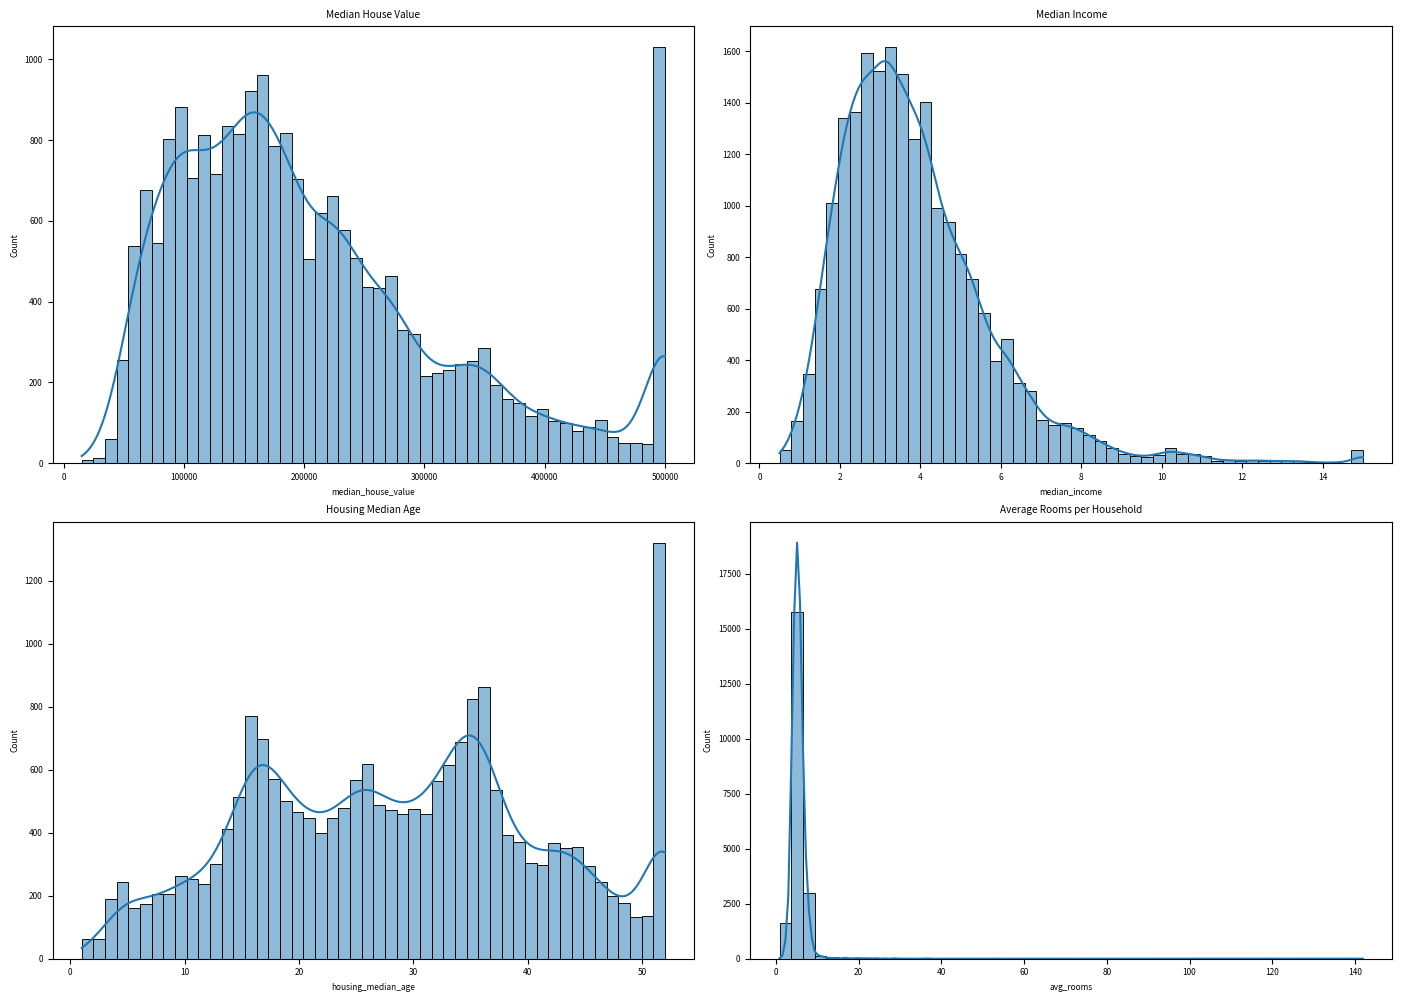

=====Median House Value=====
강한 우측 꼬리
평균은 상단 값에 끌려 왜곡
선형 회귀에서:잔차 비정상성,고가 예측 한계 발생 가능

=====Medianincom=====
우측으로 긴 꼬리
저소득 구간에 밀집, 고소득은 희소
전형적인 경제 변수 분포

=====Housing Median Age=====
1~52까지 비교적 고르게 분포
52에서 강한 수직 스파이크
52는 52년 된 집이 아니라 1940년 이전 건축을 하나로 묶은 코드
연속형 변수처럼 보이지만 사실상:
연속+범주가 섞인 혼합 변수
평균/분산 해석이 왜곡됨

=====AVG Rooms=====
중심은 3~6
우측 꼬리가 김
극단값(10~20+)존재
왜?
households가 매우 작은 지역
total_rooms는 큰 경우 발생
수학적 비율 변수의 전형적 이상치


In [165]:
import seaborn as sb
import matplotlib.pyplot as plt
my_dpi = 100
rows, cols = 2, 2

fig, axes = plt.subplots(
    rows, cols,
    figsize=(14, 10),
    dpi=my_dpi
)

df["avg_rooms"] = df["total_rooms"] / df["households"]

axes = axes.flatten()

vars_info = [
    ("median_house_value", "Median House Value"),
    ("median_income", "Median Income"),
    ("housing_median_age", "Housing Median Age"),
    ("avg_rooms", "Average Rooms per Household")
]

for ax, (col, title) in zip(axes, vars_info):
    sb.histplot(
        data=df,
        x=col,
        bins=50,
        kde=True,
        ax=ax,
        
    )
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()
print(f"=====Median House Value=====\n강한 우측 꼬리\n평균은 상단 값에 끌려 왜곡\n선형 회귀에서:잔차 비정상성,고가 예측 한계 발생 가능\n\n=====Medianincom=====\n우측으로 긴 꼬리\n저소득 구간에 밀집, 고소득은 희소\n전형적인 경제 변수 분포\n\n=====Housing Median Age=====\n1~52까지 비교적 고르게 분포\n52에서 강한 수직 스파이크\n52는 52년 된 집이 아니라 1940년 이전 건축을 하나로 묶은 코드\n연속형 변수처럼 보이지만 사실상:\n연속+범주가 섞인 혼합 변수\n평균/분산 해석이 왜곡됨"
      f"\n\n=====AVG Rooms=====\n중심은 3~6\n우측 꼬리가 김\n극단값(10~20+)존재\n왜?\nhouseholds가 매우 작은 지역\ntotal_rooms는 큰 경우 발생\n수학적 비율 변수의 전형적 이상치")

-----시계열-----<br>
📌Latitude/Longitude<br>
캘리포니아는<br>
해안 vs 내륙<br>
북부 vs 남부<br>
분포 왜곡의 상당 부분은 공간적 요인<br><br>

📌시계열 문제<br>
데이터 기준:1990년 Census<br>
현재 가격 수준과 직접 비교 불가<br>
해석은 반드시:<br>
"19190년 당시 상대적 가격" 기준

-----결론-----<br>
본 데이터의 핵심 변수들은 대부분<br>
비대칭 분포, 상한 처리, 이상치를 포함하고 있어<br>
단순 평균 기반 해석이나<br>
변환 없는 회귀 분석에 적합하지 않다.<br>
따라서 목표 변수와 설명 변수의 분포 특성을 먼저 이해하고,<br>
로그변환, 구간화, 더미 분리 등의 전처리를 통해<br>
모델 해석 가능성을 확보하는 것이 필수적

📝 미션 3. “로그/비선형 변환을 고민해 보자”<br>
MedHouseValue 혹은 주요 변수(MedInc, Population,HouseAge)<br>에 로그/제곱근 등 변환을 적용해 전후 분포
를 나란히 비교한다.<br>
변환이 해석과 모델 적합에 주는 장단점, 해석이 어떻게 달라지는지 예상한다.<br>
“이 변환이 없으면 어떤 함정에 빠질까?”를 한 줄로 정리한다.<br>
선택 기준을 명시하세요: 왜 log(MedHouseValue)인지,<br>
왜 Population에 로그인지 등 데이터 분포 근거로 설명합니다.<br>
필요한 경우 Box-Cox 등의 변환을 비교해 가장 해석 친화적인 옵션을 선택하세요.<br>
📌 출제 의도 단순히 변환을 쓰는 것이 아니라 “왜 필요했는가, 해석이 어떻게 달라지는가”를 설명하는 연습입니다.<br>

1. 핵심 가설 설정 (분석 전에 반드시 필요)<br>
가설 A (구조적 가설)<br>

오래된 주택일수록<br>

가구 수 대비 방 수가 작거나<br>

침실 비율이 다르거나<br>

주거 밀도가 다르다<br>

즉, housing_median_age는 단독 변수라기보다<br>
주거 구조 변수들과 “결합될 때” 의미를 갖는다는 가설입니다.

In [166]:
# 파생 변수 생성
df = origin.copy()

df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
df["bedroom_ratio"] = df["total_bedrooms"] / df["total_rooms"]

# housing_median_age를 "연속값"이 아니라 "구간"으로 본다
df["age_bin"] = pd.qcut(
    df["housing_median_age"],
    q=4,
    labels=["Q1(young)", "Q2", "Q3", "Q4(old)"]
)
print(f"Q4가 반드시 52만 있는지\nQ1~Q3 내부 분산이 구조 변수로 설명되는지")

Q4가 반드시 52만 있는지
Q1~Q3 내부 분산이 구조 변수로 설명되는지


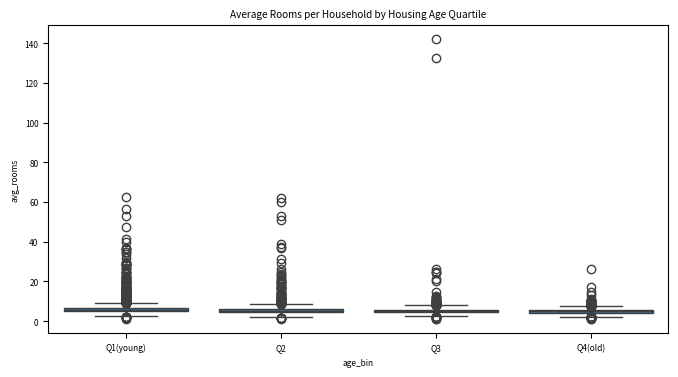

In [167]:
# age_bin vs avg_rooms
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.boxplot(x="age_bin", y="avg_rooms", data=df)
plt.title("Average Rooms per Household by Housing Age Quartile")
plt.show()


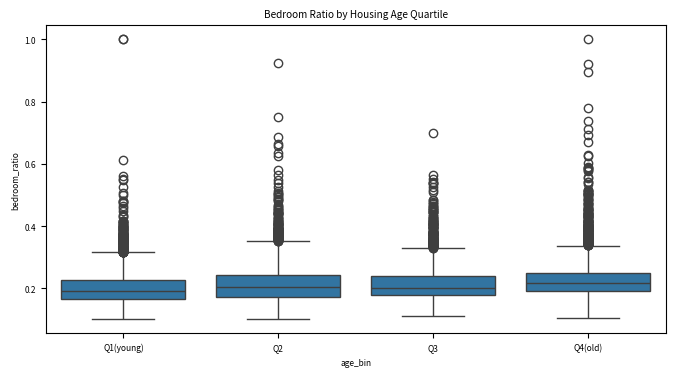

In [168]:
# age_bin vs bedroom_ratio
plt.figure(figsize=(8, 4))
sns.boxplot(x="age_bin", y="bedroom_ratio", data=df)
plt.title("Bedroom Ratio by Housing Age Quartile")
plt.show()


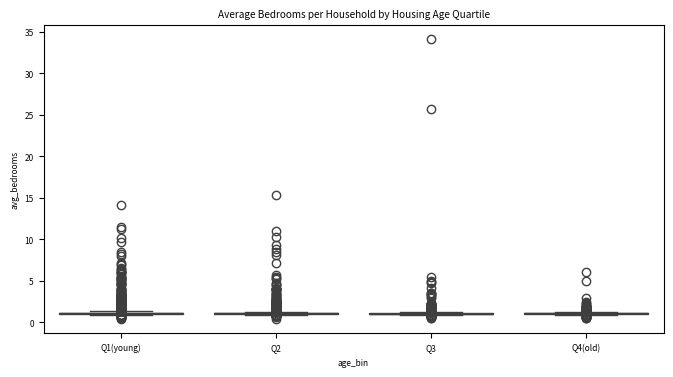

In [169]:
# age_bin vs avg_bedrooms
plt.figure(figsize=(8, 4))
sns.boxplot(x="age_bin", y="avg_bedrooms", data=df)
plt.title("Average Bedrooms per Household by Housing Age Quartile")
plt.show()


경우 ①<br>

age가 증가할수록 avg_rooms가 감소<br>

오래된 지역 = 소형 주택 위주<br>

age 분산은 실제 도시 구조 차이<br>

→ housing_median_age는 의미 있는 설명 변수<br><br>

경우 ②<br>

age와 구조 변수 간 차이가 거의 없음<br>
분산은 행정 단위/코딩 단위 노이즈<br>

→ housing_median_age 단독 사용 위험<br>

→ 다른 변수와의 interaction 필요<br><br>


경우 ③<br>

Q4(52)에서만 구조가 급격히 달라짐<br>

“1940년 이전”이라는 역사적 단층<br>

→ age_is_capped 이진 변수 도입 타당

In [170]:
# 정량적 검증(상관 + 분산 설명)
df[[
    "housing_median_age",
    "avg_rooms",
    "avg_bedrooms",
    "bedroom_ratio"
]].corr()


,housing_median_age,avg_rooms,avg_bedrooms,bedroom_ratio
housing_median_age,1.000000,-0.153277,-0.077918,0.136089
avg_rooms,-0.153277,1.000000,0.848616,-0.416952
avg_bedrooms,-0.077918,0.848616,1.000000,0.055905
bedroom_ratio,0.136089,-0.416952,0.055905,1.000000


구조 변수 × 가격의 interaction term

In [171]:
# 구조 변수 생성
df = origin.copy()

df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
df["bedroom_ratio"] = df["total_bedrooms"] / df["total_rooms"]


In [172]:
# age 상한을 분리
df["age_is_capped"] = (df["housing_median_age"] == 52).astype(int)


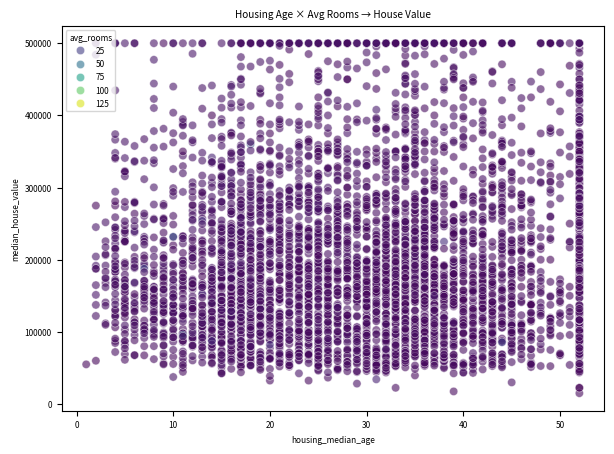

-----중요-----
housing_median_age와 avg_rooms는 주택 가격에 대해 직접적,단독적 선형 관계를 가지는 않지만,
다른 핵심 변수(특히 소득,지역)와 결합될 때
가격 분산의 구조를 설명하는 조건부 변수로 작용


In [173]:
# 1차 시각 분석: 구조 × 가격
# housing_median_age × avg_rooms → 가격
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="housing_median_age",
    y="median_house_value",
    hue="avg_rooms",
    palette="viridis",
    alpha=0.6
)
plt.title("Housing Age × Avg Rooms → House Value")
plt.show()
print(f"-----중요-----\nhousing_median_age와 avg_rooms는 주택 가격에 대해 직접적,단독적 선형 관계를 가지는 않지만,\n다른 핵심 변수(특히 소득,지역)와 결합될 때\n가격 분산의 구조를 설명하는 조건부 변수로 작용")


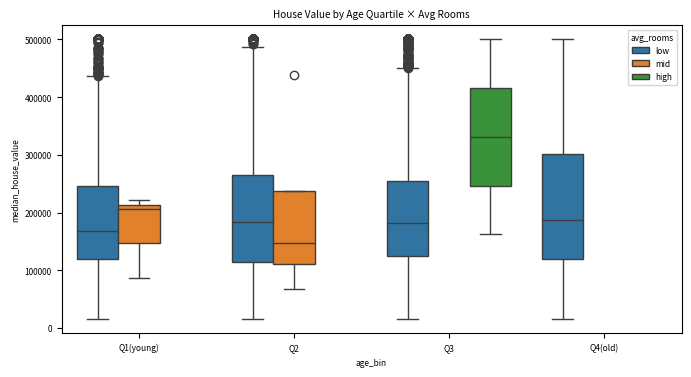

In [174]:
# age 구간별 avg_rooms × 가격
df["age_bin"] = pd.qcut(
    df["housing_median_age"],
    q=4,
    labels=["Q1(young)", "Q2", "Q3", "Q4(old)"]
)

plt.figure(figsize=(8, 4))
sns.boxplot(
    x="age_bin",
    y="median_house_value",
    hue=pd.cut(df["avg_rooms"], bins=3, labels=["low", "mid", "high"]),
    data=df
)
plt.title("House Value by Age Quartile × Avg Rooms")
plt.show()


예상대로 방 수가 많은 주택의 주택 중위 가격이 높았음.<br>
또한, 최신형 주택일 때 방 수가 적은 박스플롯이 방 수가 적은 low가
mid보다 사분위수 구간이 더 낮은 쪽에 위치함에도 불구하고 mid와 달리 이상치가 발견된 것에 의문<br>


In [175]:
# median_income 사분위 구간 생성
df = origin.copy()

# Low income, Mid-low, Mid-high, High income으로 나눔
df["income_bin"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low income", "Mid-Low", "Mid-High", "High income"]
)



C:\Users\itwill\AppData\Local\Temp\ipykernel_27412\115538815.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\itwill\AppData\Local\Temp\ipykernel_27412\115538815.py:9: UserWarning: The palette list has more values (9) than needed (4), which may not be intended.
  sns.boxplot(


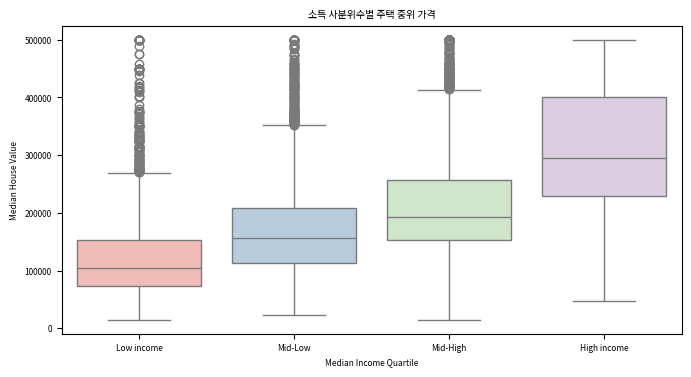

Low income에서 더 높은  소득들 보다 높은 값으로 이상치가 발견되는데
이러한 현상은 어떠한 변수로 인해 영향을 받는가?
 👉일부 고가 주택
 👉일부 고자산 가구
 👉투자 목적 보유 주택
📌 즉
소득은 “누가 많냐”를 말해주지
“누가 가장 비싼 집을 샀냐”를 말해주지 않는다.
2️⃣ 2차 원인 (가장 중요): 입지(Location) 변수의 지배력
Low income에서 나타나는 고가 이상치의 가장 강력한 원인
작동 메커니즘
해안 인접 (NEAR OCEAN, NEAR BAY)
도심 핵심 지역
개발 제한 구역
이런 곳은:
주민 소득이 낮아도
토지 희소성 + 입지 프리미엄으로 가격이 높다.

3️⃣ 3차 원인: median_house_value 상한 포화 효과
median_house_value 상한 = 500,001
High income 구간:고가 주택이 상한에 걸려 눌림
Low income 구간:일부 고가 주택이 상대적으로 더 튀어 보임
📌 결과적으로:
High income의 **진짜 고가**는 보이지 않고, Low income의 **예외적 고가**만 눈에 띈다.
4️⃣ 4차 원인: 주택 구조 변수의 영향 (방 수·밀도)
avg_rooms가 매우 크거나
ave_occup가 매우 낮은 지역
👉 대형 단독주택 + 인구 적음
소득 수준과 무관하게 주택 가격은 높아질 수 있음
📌 특히:
👉은퇴 지역
👉세컨드 하우스 지역
👉임대/투자 목적 지역


그렇다면 어떤 변수가 이러한 현상에 가장 많은 영향을 미칠까?
(가장 많이 영향을 미치는 순)
ocean_proximity > location(위도·경도) > 주택 구조 변수(avg_rooms, density)
왜 회귀에서 이 변수를 빼면 이상치가 생기나?
ocean_proximity를 포함하지 않으면:해안 프리미엄이 설명되지 않음그 결과, 고가 주택이 잔차(outlier) 로 튀어나옴


In [176]:
df["income_bin"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low income", "Mid-Low", "Mid-High", "High income"]
)

palette = sns.color_palette('Pastel1')
plt.figure(figsize=(8, 4))
sns.boxplot(
    x="income_bin",
    y="median_house_value",
    data=df,
    palette = palette
)

plt.title("소득 사분위수별 주택 중위 가격")
plt.xlabel("Median Income Quartile")
plt.ylabel("Median House Value")
plt.show()
print(f"Low income에서 더 높은  소득들 보다 높은 값으로 이상치가 발견되는데\n이러한 현상은 어떠한 변수로 인해 영향을 받는가?\n 👉일부 고가 주택\n 👉일부 고자산 가구\n 👉투자 목적 보유 주택\n📌 즉\n소득은 “누가 많냐”를 말해주지\n“누가 가장 비싼 집을 샀냐”를 말해주지 않는다.")
print(f"2️⃣ 2차 원인 (가장 중요): 입지(Location) 변수의 지배력\nLow income에서 나타나는 고가 이상치의 가장 강력한 원인\n작동 메커니즘\n해안 인접 (NEAR OCEAN, NEAR BAY)\n도심 핵심 지역\n개발 제한 구역\n이런 곳은:\n주민 소득이 낮아도\n토지 희소성 + 입지 프리미엄으로 가격이 높다.\n")
print(f"3️⃣ 3차 원인: median_house_value 상한 포화 효과\nmedian_house_value 상한 = 500,001\nHigh income 구간:고가 주택이 상한에 걸려 눌림\nLow income 구간:일부 고가 주택이 상대적으로 더 튀어 보임\n📌 결과적으로:\nHigh income의 **진짜 고가**는 보이지 않고, Low income의 **예외적 고가**만 눈에 띈다.")
print(f"4️⃣ 4차 원인: 주택 구조 변수의 영향 (방 수·밀도)\navg_rooms가 매우 크거나\nave_occup가 매우 낮은 지역\n👉 대형 단독주택 + 인구 적음\n소득 수준과 무관하게 주택 가격은 높아질 수 있음\n📌 특히:\n👉은퇴 지역\n👉세컨드 하우스 지역\n👉임대/투자 목적 지역")
print(f"\n\n그렇다면 어떤 변수가 이러한 현상에 가장 많은 영향을 미칠까?\n(가장 많이 영향을 미치는 순)\nocean_proximity > location(위도·경도) > 주택 구조 변수(avg_rooms, density)")
print(f"왜 회귀에서 이 변수를 빼면 이상치가 생기나?\nocean_proximity를 포함하지 않으면:해안 프리미엄이 설명되지 않음그 결과, 고가 주택이 잔차(outlier) 로 튀어나옴")

1순위 변수: 해안 접근성<br>
소득보다 집값에 더 직접적으로 작용<br>
저소득 주민이 많이 사는 지역이라도 해안에 붙어있으면 가격은 높아진다.<br>
그렇다면 Low income일수록 해안에 거주하는 사람들이 많은가?<br><br>

2순위 변수: 위치 좌표 (latitude, longitude)<br>
왜 소득보다 강한가?<br>
👉Low income 고가 이상치의 전형적 위치<br>
👉샌프란시스코 인근<br>
👉LA 해안 인접<br>
👉베이 에어리어 외곽<br>
이 지역의 특징:<br>
평균 소득은 낮아도 토지 가격 자체가 비쌈<br>
📌 그래서:<br>
위치 변수를 통제하지 않으면<br>
소득의 효과가 과대평가되고,<br>
위치 프리미엄이 “이상치”로 나타난다.<br><br>

3️⃣ 3순위 변수: 주택 구조 변수 (avg_rooms, density)<br>
→ 은퇴 지역, 세컨드 하우스, 투자용 주택

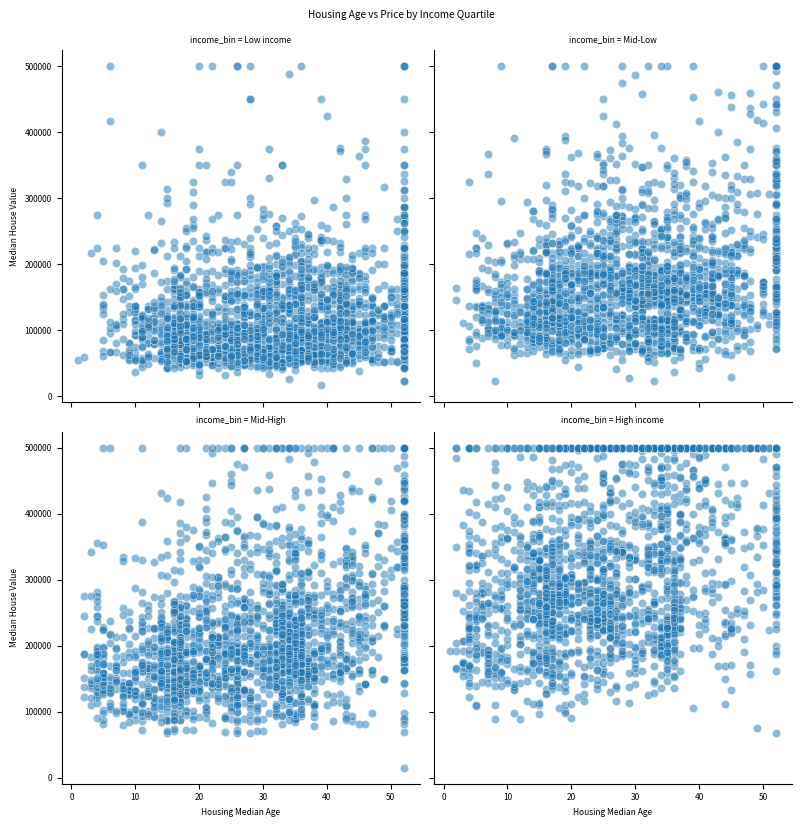

-----가격의 분산 구조-----
같은 소득 수준에서, 주택 연령이 가격 분포에 어떤 역할을 하는가소득이 통제된 상태에서의 조건부 현상

income_bin이 Mid_High인 패널에에서는 소득자체가 고가 형성을 허용함.
즉, 가격 상한이 열린 상태
오래된 집 중에서도 입지 좋고 역사적 주거지인 곳들이 고가로 남아있음
고소득 지역에서는 오래된 집도 비쌀 수 있다

Low income일 경우
가격 상단이 약 200k 전후에서 제한
age증가에도 상단이 거의 안 움직임
분산도 비교적 작음
-->소득이 낮으면 오래된 집이여도 고가 형성 불가
Mid-Low income일 경우
가격 상단이 약 300k까지 확장
age 증가와 함께 분산이 약간 커짐
age가 단독 요인으로 작동하기 시작
하지만 여전히 소득이 가격을 지배

Mid-High income일 경우
상단이 400~500k까지 열림
age 20~40구간에서 고가 밀집
주택 연령이 노후가 아니라 성숙한 주거지를 의미하는 구간 존재
age효과가 비선형적

High income
전 연령대에서 고가 존재
52(상한)에서 고가가 집중
분산이 매우 큼


In [177]:
# 소득 구간별로 age x price 산점도
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    df.sample(8000, random_state=42),
    col="income_bin",
    col_wrap=2,
    height=4,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="housing_median_age",
    y="median_house_value",
    alpha=0.5
)

g.set_axis_labels("Housing Median Age", "Median House Value")
g.fig.suptitle("Housing Age vs Price by Income Quartile", y=1.02)

plt.show()
print(f"-----가격의 분산 구조-----\n같은 소득 수준에서, 주택 연령이 가격 분포에 어떤 역할을 하는가"
      f"소득이 통제된 상태에서의 조건부 현상\n\nincome_bin이 Mid_High인 패널에에서는 소득자체가 고가 형성을 허용함.\n즉, 가격 상한이 열린 상태\n오래된 집 중에서도 입지 좋고 역사적 주거지인 곳들이 고가로 남아있음\n고소득 지역에서는 오래된 집도 비쌀 수 있다"
      f"\n\nLow income일 경우\n가격 상단이 약 200k 전후에서 제한\nage증가에도 상단이 거의 안 움직임\n분산도 비교적 작음\n-->소득이 낮으면 오래된 집이여도 고가 형성 불가"
      f"\nMid-Low income일 경우\n가격 상단이 약 300k까지 확장\nage 증가와 함께 분산이 약간 커짐\nage가 단독 요인으로 작동하기 시작\n하지만 여전히 소득이 가격을 지배"
      f"\n\nMid-High income일 경우\n상단이 400~500k까지 열림\nage 20~40구간에서 고가 밀집\n주택 연령이 노후가 아니라 성숙한 주거지를 의미하는 구간 존재\nage효과가 비선형적"
      f"\n\nHigh income\n전 연령대에서 고가 존재\n52(상한)에서 고가가 집중\n분산이 매우 큼")

📝미션 3. “로그/비선형 변환을 고민해 보자”<br>
MedHouseValue 혹은 주요 변수(MedInc, Population, HouseAge)에 로그/제곱근 등 변환을 적용해 전후 분포를 나란히 비교한다.<br>
변환이 해석과 모델 적합에 주는 장단점, 해석이 어떻게 달라지는지 예상한다.“이 변환이 없으면 어떤 함정에 빠질까?”를 한 줄로 정리한다.<br>
선택 기준을 명시하세요: 왜 log(MedHouseValue)인지, 왜 Population에 로그인지 등 데이터 분포 근거로 설명합니다<br>

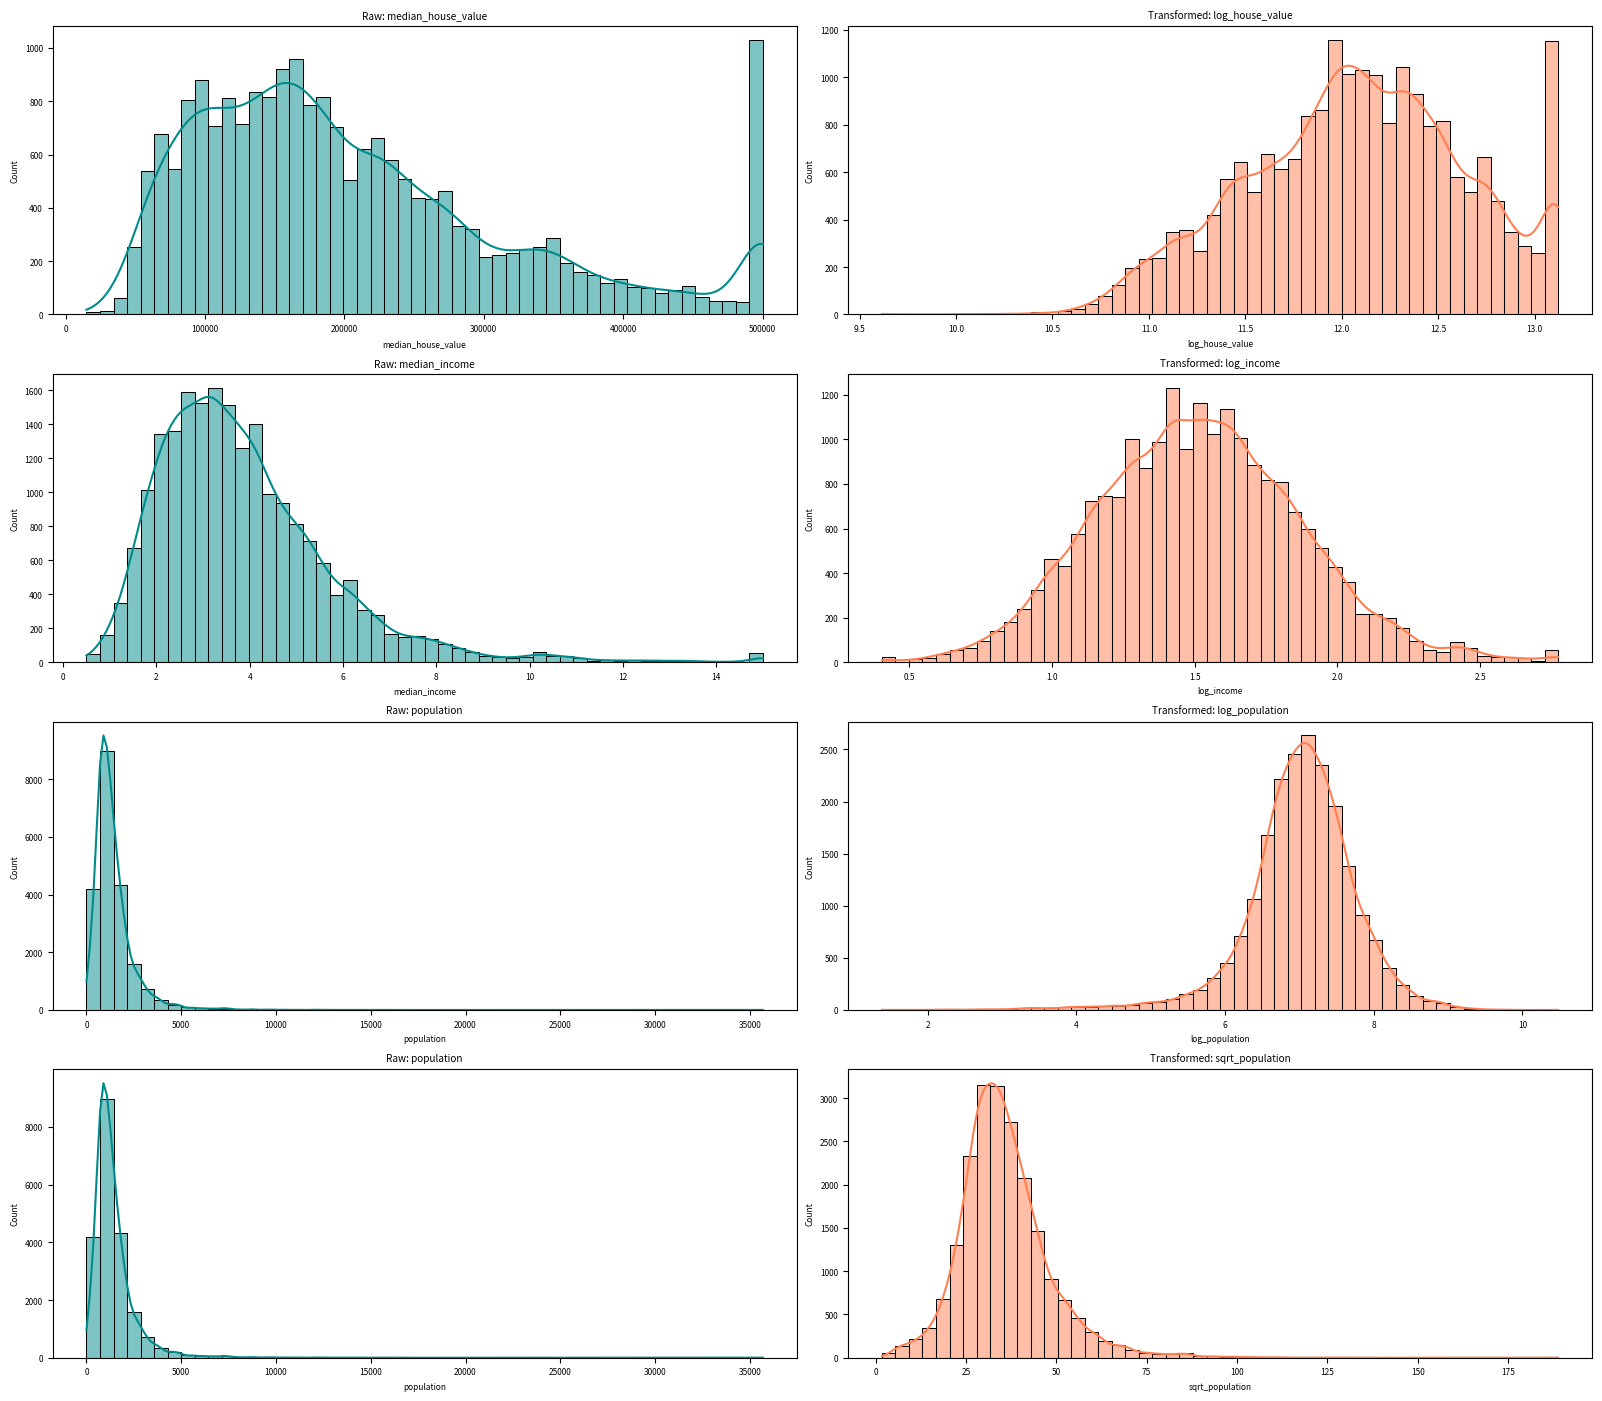

In [178]:

df = origin.copy()

# 파생 변수
df["avg_rooms"] = df["total_rooms"] / df["households"]

# 1️⃣ 변환 대상 변수 선택 (미션 명시)
# 목표변수: median_house_value
# 설명변수: median_income, population, housing_median_age


# 로그 / 제곱근 변환 적용
# (1) 로그 변환 (log1p: 0 대비 안전)
df["log_house_value"] = np.log1p(df["median_house_value"])
df["log_income"] = np.log1p(df["median_income"])
df["log_population"] = np.log1p(df["population"])

# (2) 제곱근 변환 (비교용)
df["sqrt_population"] = np.sqrt(df["population"])

# 변환 전/후 분포 비교 (나란히)
compare_pairs = [
    ("median_house_value", "log_house_value"),
    ("median_income", "log_income"),
    ("population", "log_population"),
    ("population", "sqrt_population")
]

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for i, (raw, trans) in enumerate(compare_pairs):

    sns.histplot(df[raw], bins=50, kde=True, ax=axes[i, 0], color = 'darkcyan')
    axes[i, 0].set_title(f"Raw: {raw}")

    sns.histplot(df[trans], bins=50, kde=True, ax=axes[i, 1], color = 'coral')
    axes[i, 1].set_title(f"Transformed: {trans}")

plt.tight_layout()
plt.show()


로그 변환 후, median_income이 정규성 분포를 띔<br>

<br>📌 선택 기준<br>
- median_house_value: 우측 편향 + 상한 포화 → log 필수<br>
- median_income: 경제 변수 특성상 비대칭 → log 권장<br>
- population: 규모 변수 → log 필수<br>
- housing_median_age: 절단 분포 → 로그보다 구간화/더미가 적절


📝미션 4. “지리적 위치는 정말 중요할까?”위도(Latitude)와 경도(Longitude)를 활용한 지리적 시각화를 수행한다.<br>
산점도(경도 × 위도, 점의 색상 = MedHouseValue)를 그려 주택 가격의 지리적 불평등을 관찰한다.<br>
“어느 지역이 비싼가?”, “가격 차이가 얼마나 뚜렷한가?”를 데이터 기반으로 설명하세요.<br>
위도/경도가 개별 변수보다 지역 표상(Proxy)이라는 점을 인식하고,<br> 이것이 회귀에 주는 의미를 논의하세요.

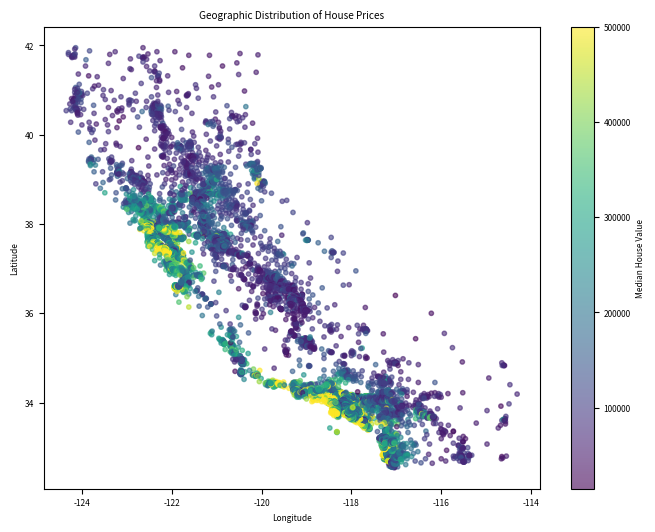

In [179]:
# 위도·경도 기반 가격 분포 시각화
plt.figure(figsize=(8, 6))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap="viridis",
    s=10,
    alpha=0.6
)

plt.colorbar(label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of House Prices")
plt.show()


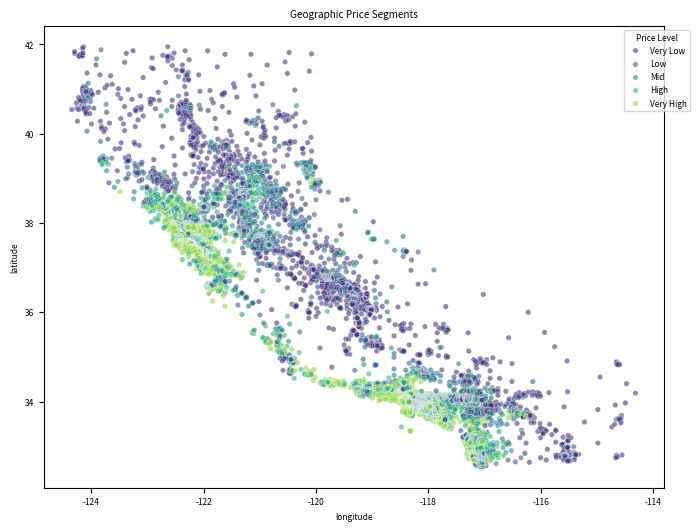

In [180]:
# 산점도 + 가격 구간 색상 분리
df["price_bin"] = pd.qcut(
    df["median_house_value"],
    q=5,
    labels=["Very Low", "Low", "Mid", "High", "Very High"]
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="price_bin",
    palette="viridis",
    s=15,
    alpha=0.6
)

plt.title("Geographic Price Segments")
plt.legend(title="Price Level", bbox_to_anchor=(1.05, 1))
plt.show()


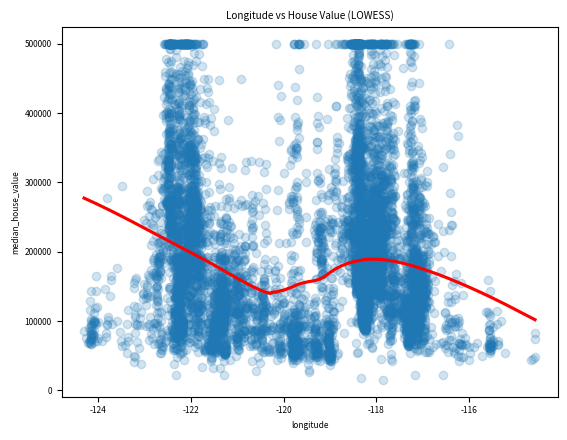

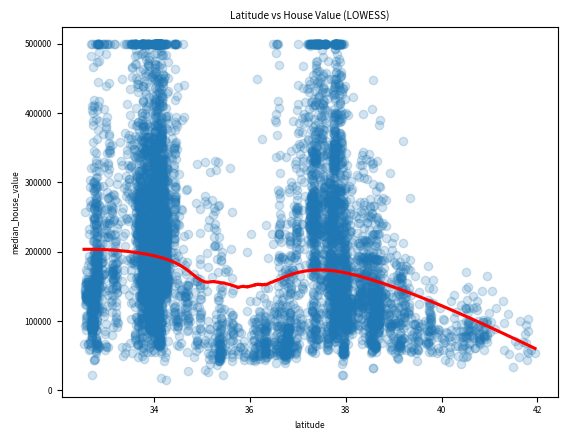

Longitude vs House Value에서 왜 내륙 지역에서 집값이 올라가냐?
조건부 변수 때문에
📌 약한 선형회귀 -> “그 경도에 어떤 지역들이 몰려 있느냐”


In [181]:
# 위치 vs 가격: 비선형성 확인
sns.regplot(
    data=df.sample(8000, random_state=42),
    x="longitude",
    y="median_house_value",
    lowess=True,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)
plt.title("Longitude vs House Value (LOWESS)")
plt.show()
sns.regplot(
    data=df.sample(8000, random_state=42),
    x="latitude",
    y="median_house_value",
    lowess=True,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)
plt.title("Latitude vs House Value (LOWESS)")
plt.show()
print(f"Longitude vs House Value에서 왜 내륙 지역에서 집값이 올라가냐?\n조건부 변수 때문에\n📌 약한 선형회귀 -> “그 경도에 어떤 지역들이 몰려 있느냐”")

In [182]:
# 상관계수로 보면 왜 “위치가 약해 보이는지”
sangwan = df[[
    "latitude",
    "longitude",
    "median_house_value"
]].corr()
print(f"위도·경도는 가격과 강한 비선형 관계를 가지므로\n단순 Pearson 상관계수는 위치 효과를 과소평가한다.")
print(f"하지만 latitude와 median_house_value간의 음의 상관계수가 다소 강한 것으로 보아,  북쪽에 위치한 집일수록 집값이 저렴하다는 것을 알 수 있다.")
print(sangwan)

위도·경도는 가격과 강한 비선형 관계를 가지므로
단순 Pearson 상관계수는 위치 효과를 과소평가한다.
하지만 latitude와 median_house_value간의 음의 상관계수가 다소 강한 것으로 보아,  북쪽에 위치한 집일수록 집값이 저렴하다는 것을 알 수 있다.
                    latitude  longitude  median_house_value
latitude            1.000000  -0.924664           -0.144160
longitude          -0.924664   1.000000           -0.045967
median_house_value -0.144160  -0.045967            1.000000


In [183]:
# 토지 독점력 지표 생성 (Distance 기반)


COAST_LON = -120  # 해안 근사 기준선 (캘리포니아 평균 해안 경도)

df["dist_to_coast"] = np.abs(df["longitude"] - COAST_LON)

In [184]:
# 주요 해안·도심 축 거리 (SF / LA)


sf_lat, sf_lon = 37.77, -122.42                 # 주요 해안 도시 좌표
la_lat, la_lon = 34.05, -118.25      


df["dist_to_sf"] = np.sqrt(
    (df["latitude"] - sf_lat)**2 + (df["longitude"] - sf_lon)**2
)

df["dist_to_la"] = np.sqrt(
    (df["latitude"] - la_lat)**2 + (df["longitude"] - la_lon)**2
)

# 더 가까운 쪽을 대표 도심 거리로 사용
df["dist_to_city"] = df[["dist_to_sf", "dist_to_la"]].min(axis=1)

In [185]:
# 2️⃣ 토지 독점력 구간화 (핵심)
# (1) 해안 독점력 구간 (분위수 기준)
df["coast_power"] = pd.qcut(
    df["dist_to_coast"],
    q=4,
    labels=[
        "Very High Land Dominance (Coastal)",
        "High",
        "Medium",
        "Low (Inland)"
    ]
)

In [186]:
# (2) 도심 독점력 구간
df["city_power"] = pd.qcut(
    df["dist_to_city"],
    q=4,
    labels=[
        "Core Urban",
        "Inner Urban",
        "Suburban",
        "Peripheral"
    ]
)

C:\Users\itwill\AppData\Local\Temp\ipykernel_27412\3780805773.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


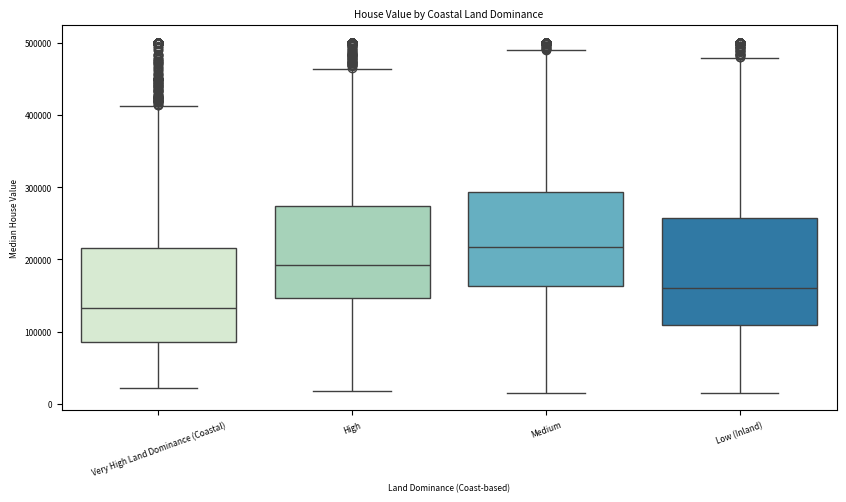

“해안이 가장 비싸야 하는데 왜 하단이 싸 보이지?”
1️⃣ 가장 중요한 1차 원인
🔹 A. 초고가 해안 (SF, Malibu, Santa Monica)
토지 희소성 ↑
고소득 수요 ↑
가격 상단 형성
🔹 B. 저가 해안 (Central Valley 인근, 낙후된 해안 소도시)
관광지 아님
산업·항만·농업 연계
주거 수요 낮음📌 Very High Land Dominance는 ‘해안 접근성’만 반영
→ ‘부촌 여부’는 반영하지 않음
👉 전형적인 ‘혼합 분포(mixture distribution)’

2️⃣ 2차 원인
Very High Land Dominance는:
“바다와 가깝다”는 뜻이지
“살기 좋은 동네다”는 뜻이 아니다
해안에는 다음도 많다:
오래된 주택
저소득 어업·항만 노동자 주거지
관광 비수기 지역

3️⃣ 3차 원인
Very High 그룹은:
분산이 가장 큼
저가 해안이 포함되면
→ Q1이 급격히 내려감
반면:
High / Medium 그룹은
내륙 도시 위주
가격 분포가 더 균질
Q1이 상대적으로 높아 보임
📌 이건 역설이 아니라:
분산이 클수록 Q1은 내려간다
라는 통계적 성질


In [187]:
# (1) 해안 독점력별 가격 분포

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="coast_power",
    y="median_house_value",
    palette = "GnBu"
)
plt.xticks(rotation=20)
plt.title("House Value by Coastal Land Dominance")
plt.ylabel("Median House Value")
plt.xlabel("Land Dominance (Coast-based)")
plt.show()
print(f"“해안이 가장 비싸야 하는데 왜 하단이 싸 보이지?”")
print(f"1️⃣ 가장 중요한 1차 원인\n🔹 A. 초고가 해안 (SF, Malibu, Santa Monica)\n토지 희소성 ↑\n고소득 수요 ↑\n가격 상단 형성\n🔹 B. 저가 해안 (Central Valley 인근, 낙후된 해안 소도시)\n관광지 아님\n산업·항만·농업 연계\n주거 수요 낮음📌 Very High Land Dominance는 ‘해안 접근성’만 반영\n→ ‘부촌 여부’는 반영하지 않음\n👉 전형적인 ‘혼합 분포(mixture distribution)’\n")
print(f"2️⃣ 2차 원인\nVery High Land Dominance는:\n“바다와 가깝다”는 뜻이지\n“살기 좋은 동네다”는 뜻이 아니다\n해안에는 다음도 많다:\n오래된 주택\n저소득 어업·항만 노동자 주거지\n관광 비수기 지역\n")
print(f"3️⃣ 3차 원인\nVery High 그룹은:\n분산이 가장 큼\n저가 해안이 포함되면\n→ Q1이 급격히 내려감")
print(f"반면:\nHigh / Medium 그룹은\n내륙 도시 위주\n가격 분포가 더 균질\nQ1이 상대적으로 높아 보임\n📌 이건 역설이 아니라:\n분산이 클수록 Q1은 내려간다\n라는 통계적 성질")

3️⃣ 토지 독점력 × 주택 중위가격 매칭

C:\Users\itwill\AppData\Local\Temp\ipykernel_27412\2473213424.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


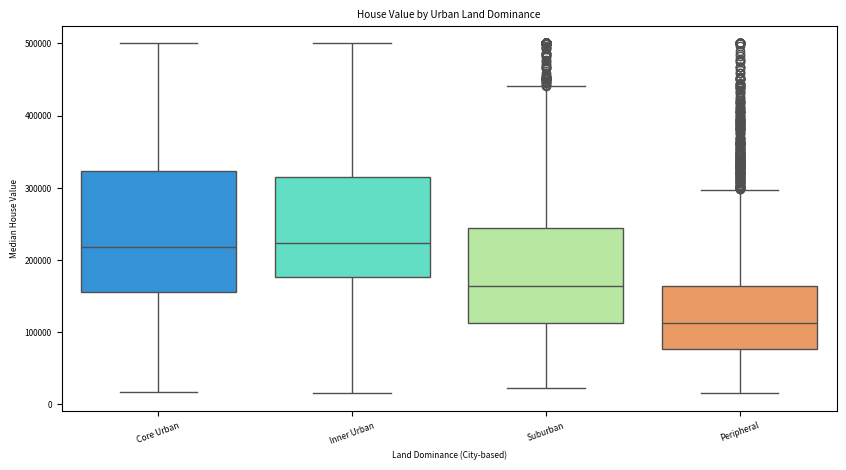

In [188]:
# (2) 도심 독점력별 가격 분포
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="city_power",
    y="median_house_value",
    palette = "rainbow"
)
plt.xticks(rotation=20)
plt.title("House Value by Urban Land Dominance")
plt.ylabel("Median House Value")
plt.xlabel("Land Dominance (City-based)")
plt.show()


가설 A (분포 하단 검증 – 핵심)

H₀ (귀무가설) Peripheral 지역과 Urban 지역의 하위 가격대(Q1) 는 차이가 없다.

H₁ (대립가설) Peripheral 지역의 하위 가격대(Q1) 가 Urban 지역보다 낮다.

→ 왜 평균이 아니라 Q1? 👉 “사분위 시작 구간이 낮다”는 시각적 주장과 정확히 일치

In [189]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# =========================
# 1. 데이터 준비
# =========================
df_test = df[
    df["city_power"].isin(["Peripheral", "Core Urban", "Inner Urban"])
].copy()

peripheral = df_test[df_test["city_power"] == "Peripheral"]["median_house_value"]
urban = df_test[df_test["city_power"].isin(["Core Urban", "Inner Urban"])]["median_house_value"]

# =========================
# 2. Mann–Whitney U Test (단측)
# =========================
u_stat, p_two = mannwhitneyu(
    peripheral,
    urban,
    alternative="less"   # Peripheral < Urban
)

# =========================
# 3. 사분위수 비교
# =========================
q1_peripheral = np.percentile(peripheral, 25)
q1_urban = np.percentile(urban, 25)

# =========================
# 4. 결과 해석
# =========================
if p_two < 0.01:
    sig = "매우 유의미하다 (p < 0.01)"
elif p_two < 0.05:
    sig = "유의미하다 (p < 0.05)"
else:
    sig = "통계적으로 유의하지 않다"

report = f"""
[Peripheral 해안 지역 하위 가격대 검증 결과]

Peripheral 지역의 1사분위(Q1) 주택가격은 {q1_peripheral:,.0f},
Urban(Core/Inner) 지역의 1사분위는 {q1_urban:,.0f}로 나타났다.

Mann–Whitney U 단측 검정 결과,
U-statistic = {u_stat:,.0f}
p-value = {p_two:.4f}

따라서 Peripheral 지역의 하위 주택가격대는
Urban 지역보다 {sig} 수준으로 낮다.

이는 해안 프리미엄이 지역 전체에 균등하게 작용하지 않고,
일부 고급 enclave에만 집중된다는 가설을 지지한다.
"""

print(report)
print(f"하지만, CLUSTER 4,5를 따로 비교했을 때와 결과가 다르게 나오는 이유는\n해당 분석에서는 ocean proximity 전체 관측치를 조건변수로 두었기 때문에 결과가 다르게 나오는 것 같다고 판단했다")


[Peripheral 해안 지역 하위 가격대 검증 결과]

Peripheral 지역의 1사분위(Q1) 주택가격은 75,975,
Urban(Core/Inner) 지역의 1사분위는 164,600로 나타났다.

Mann–Whitney U 단측 검정 결과,
U-statistic = 9,408,755
p-value = 0.0000

따라서 Peripheral 지역의 하위 주택가격대는
Urban 지역보다 매우 유의미하다 (p < 0.01) 수준으로 낮다.

이는 해안 프리미엄이 지역 전체에 균등하게 작용하지 않고,
일부 고급 enclave에만 집중된다는 가설을 지지한다.

하지만, CLUSTER 4,5를 따로 비교했을 때와 결과가 다르게 나오는 이유는
해당 분석에서는 ocean proximity 전체 관측치를 조건변수로 두었기 때문에 결과가 다르게 나오는 것 같다고 판단했다


In [190]:
import pandas as pd

# 1. 데이터 불러오기
df = origin.copy()

# 2. 좌표 기반으로 도시 라벨링 함수 정의 (각 도시의 대략적인 범위 설정)
def classify_city(row):
    lon, lat = row['longitude'], row['latitude']
    
    # 말리부 (초고가)
    if -119.0 <= lon <= -118.6 and 34.0 <= lat <= 34.1:
        return 'Malibu'
    # 샌타모니카 (고가)
    elif -118.55 <= lon <= -118.4 and 33.98 <= lat <= 34.06:
        return 'Santa Monica'
    # 샌피드로 (저가 해안)
    elif -118.35 <= lon <= -118.25 and 33.70 <= lat <= 33.77:
        return 'San Pedro'
    # 롱비치 (저가 해안)
    elif -118.25 <= lon <= -118.05 and 33.74 <= lat <= 33.9:
        return 'Long Beach'
    return None

# 3. 도시 분류 적용 및 필터링
df['city'] = df.apply(classify_city, axis=1)
target_df = df[df['city'].notnull()].copy()

# 4. 분석 그룹 추가 (시각화 시 색상 구분을 위해)
high_cost = ['Malibu', 'Santa Monica']
target_df['group'] = target_df['city'].apply(lambda x: 'Ultra-High' if x in high_cost else 'Affordable')

# 5. QGIS용 파일 저장 및 결과 출력
target_df.to_csv('coastal_analysis.csv', index=False)

print("--- 지역별 주택 중위가격 분석 결과 ---")
summary = target_df.groupby('city')['median_house_value'].median().sort_values(ascending=False)
print(summary)
print(f"모두 로스엔젤러스에 있음")

--- 지역별 주택 중위가격 분석 결과 ---
city
Malibu          500001.0
Santa Monica    394700.0
San Pedro       274900.0
Long Beach      194000.0
Name: median_house_value, dtype: float64
모두 로스엔젤러스에 있음


🔹 소득 분위별 위치 × 가격

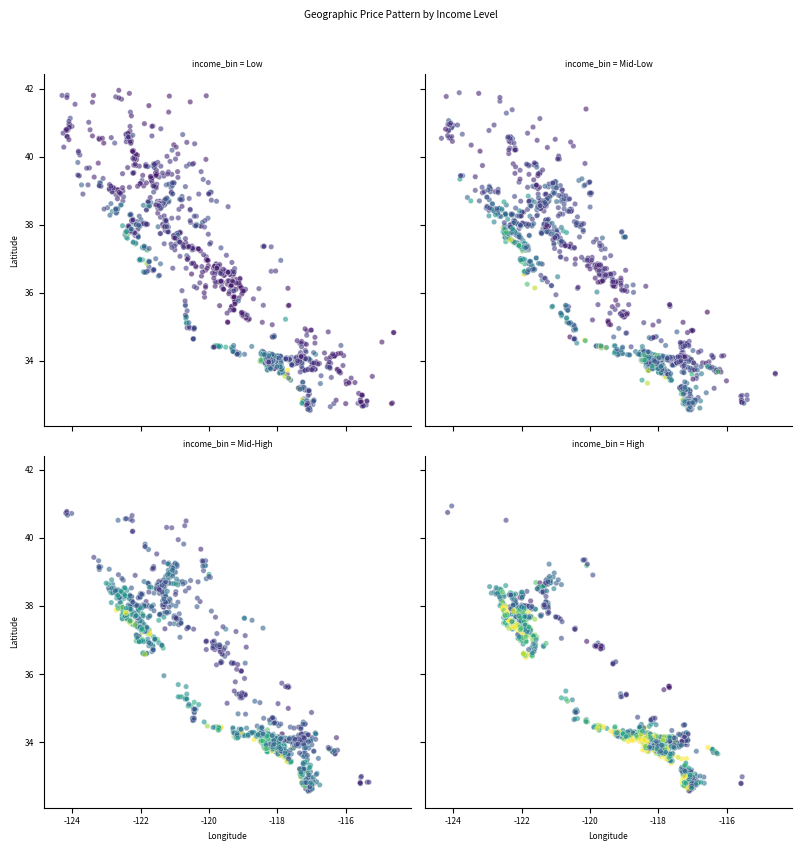

In [191]:
# 소득 분위 생성
df["income_bin"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

# FacetGrid 생성
g = sns.FacetGrid(
    df.sample(10000, random_state=42),
    col="income_bin",
    col_wrap=2,
    height=4,
    sharex=True,
    sharey=True
)

# scatterplot (색 = 집값)
g.map_dataframe(
    sns.scatterplot,
    x="longitude",
    y="latitude",
    hue="median_house_value",
    palette="viridis",
    legend=False,
    s=15,
    alpha=0.6
)

g.set_axis_labels("Longitude", "Latitude")
g.fig.suptitle("Geographic Price Pattern by Income Level", y=1.05)

plt.show()

📝미션 5. “소득은 정말로 집값을 결정할까?"

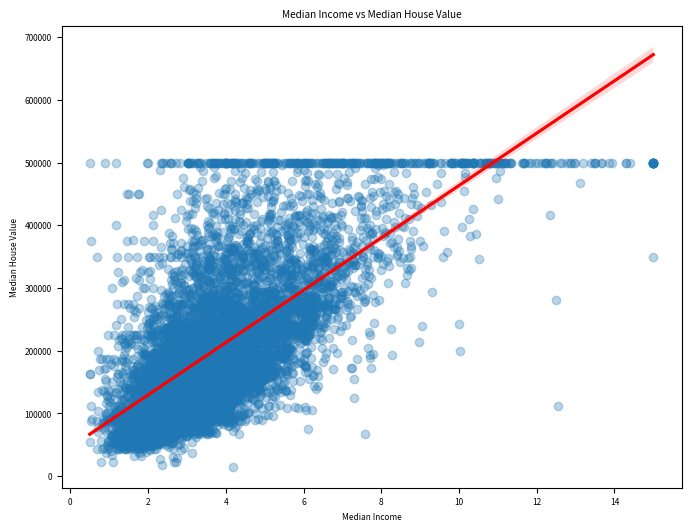

소득 증가할수록 가격 분산 확대
확실히 저소득 구간에 거주하는 사람들이 많음


In [192]:
# 1️⃣ MedInc에 따른 MedHouseValue 산점도 + 회귀선
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df.sample(8000, random_state=42),
    x="median_income",
    y="median_house_value",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()
print(f"소득 증가할수록 가격 분산 확대\n확실히 저소득 구간에 거주하는 사람들이 많음")

C:\Users\itwill\AppData\Local\Temp\ipykernel_27412\2946070744.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


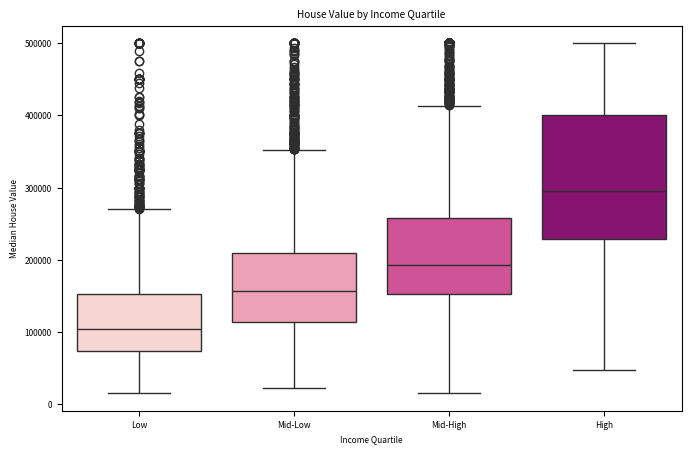

In [193]:
# 2️⃣ 소득 사분위수별 가격 분포
df["income_bin"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="income_bin",
    y="median_house_value",
    palette="RdPu"
)

plt.title("House Value by Income Quartile")
plt.xlabel("Income Quartile")
plt.ylabel("Median House Value")
plt.show()


_사분위수를 보고 Low가 다른 변수들 보다 높은 이상치들이 있다는 것을 발견_<br>
_실제로 가장 높은 가격에 속하는 500001 달러의 주택이 고소득 구간이라는 것을 확인_<br>
_500001달러의 주택이 어느 지역에 속하는지 확인_


In [194]:
# 사분위수를 보고 Low가 다른 변수들 보다 높은 이상치들이 있다는 것을 발견
# 실제로 가장 높은 가격에 속하는 500001 달러의 주택이 고소득 구간이라는 것을 확인


# -----코드 설명-----
# 가격 상한(포화) 주택만 추출


cap_value = 500001
df_cap = df[df["median_house_value"] == cap_value]

print(f"Malibu에 거주하는 사람들: {len(df_cap)}")


# 소득 사분위수 생성
df["income_quartile"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

# 상한 주택에 분위 정보 붙이기
df_cap = df_cap.merge(
    df[["median_income", "income_quartile"]],
    left_index=True,
    right_index=True,
    how="left"
)
print(f"알고보니까 Malibu")

Malibu에 거주하는 사람들: 965
알고보니까 Malibu


_상한주택내에서 소득 4분위 매칭_

In [195]:
# 1️⃣ 전체 데이터 기준으로 소득 분위 생성
df["income_quartile"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

# 2️⃣ 가격 상한 주택만 필터링
df_cap = df[df["median_house_value"] == 500001]

# 3️⃣ 이제 정상 작동
income_dist = (
    df_cap["income_quartile"]
    .value_counts(normalize=True)
    .sort_index()
)

income_dist


income_quartile
Low         0.024870
Mid-Low     0.047668
Mid-High    0.129534
High        0.797927
Name: proportion, dtype: float64

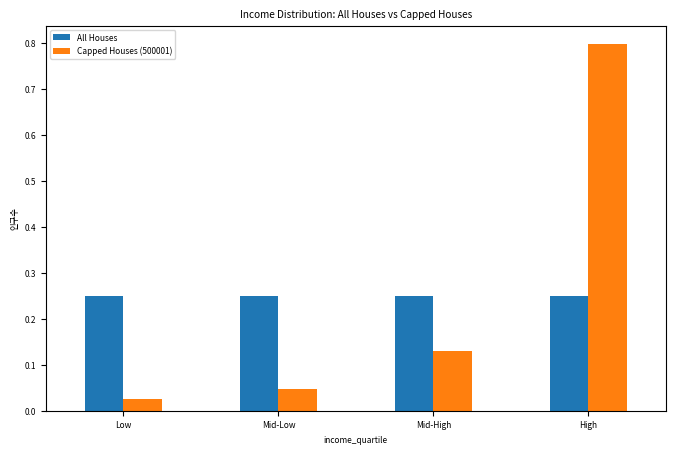

소득분위 각 구간마다 500001의 값을 갖는 상한 주택이 존재. 
하지만 역시 high에서 상한 주택의 수가 가장 많았음
역시 소득이 높을수록 고가 주택에 거주한다는 사실을 알 수 있음


In [196]:
# 시각화: 상한 주택 vs 전체 비교
df["income_quartile"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)
# 싱한만 필터링
capped_df = df[df["median_house_value"] == 500001]

compare_df = pd.DataFrame({
    "All Houses": df["income_quartile"].value_counts(normalize=True),
    "Capped Houses (500001)": capped_df["income_quartile"].value_counts(normalize=True)
}).sort_index()

compare_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Income Distribution: All Houses vs Capped Houses")
plt.ylabel("인구수")
plt.xticks(rotation=0)
plt.show()
print(f"소득분위 각 구간마다 500001의 값을 갖는 상한 주택이 존재. \n하지만 역시 high에서 상한 주택의 수가 가장 많았음")
print(f"역시 소득이 높을수록 고가 주택에 거주한다는 사실을 알 수 있음")


In [197]:
ratio = len(capped_df) / len(df) * 100
print(f"말리부 주택수: {len(capped_df)}개 ({ratio:.2f}%)")
print(f"4.68%가 각 구간별로 어떻게 배치되는지")

말리부 주택수: 965개 (4.68%)
4.68%가 각 구간별로 어떻게 배치되는지


상한 여부 이진 변수 생성

In [198]:
df["is_capped"] = (df["median_house_value"] == 500001).astype(int)
(df["median_house_value"] == 500001).mean()


np.float64(0.04675387596899225)

소득 사분위에 상한 주택이 몰려 있는가?

In [199]:
df["is_capped"] = (df["median_house_value"] == 500001).astype(int)

df["income_quartile"] = pd.qcut(
    df["median_income"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

cont_table = pd.crosstab(
    df["income_quartile"],
    df["is_capped"]
)

cont_table


is_capped,0,1
income_quartile,,
Low,5136,24
Mid-Low,5114,46
Mid-High,5035,125
High,4390,770


1: 상한 주택<br>
0: 일반 주택

카이제곱 독립성 검정<br>
분산이 소득 사분위의 경계를 무너뜨리는지 확인

귀무가설 (H₀)

“소득 분위와 상한 주택 여부는 서로 독립이다”

대립가설 (H₁)

“소득 분위에 따라 상한 주택 발생 확률이 다르다”

In [200]:
from scipy import stats
import numpy as np

def chi2_result_to_string(cont_table, alpha=0.05):
    chi2, p, dof, expected = stats.chi2_contingency(cont_table)
    
    decision = (
        "귀무가설 기각 (독립 아님)"
        if p < alpha else
        "귀무가설 기각 불가 (독립 가정 가능)"
    )
    
    # 관측 비율 계산 (상한 주택 비율)
    observed = cont_table.copy()
    observed_ratio = observed.div(observed.sum(axis=1), axis=0)
    
    result_str = f"""
[카이제곱 독립성 검정 결과]

- 검정 대상:
  · 행 변수: 소득 분위 (income_quartile)
  · 열 변수: 상한 주택 여부 (1 = capped, 0 = 일반)

- Chi-square statistic : {chi2:.3f}
- Degrees of freedom   : {dof}
- p-value               : {p:.6f}

→ 유의수준 {alpha} 기준 판단:
  {decision}

[해석]
- p-value가 매우 작아 소득 분위와 상한 주택 여부는 통계적으로 독립이 아님
- 즉, 주택 가격 상한(censoring)은 소득 분위에 따라 체계적으로 발생
- 이는 상위 소득 분위에서 상한 주택이 집중됨을 의미

[참고: 소득 분위별 상한 주택 비율]
{(observed_ratio[1] * 100).round(2).astype(str) + " %"}
"""
    return result_str


In [201]:
print(chi2_result_to_string(cont_table))



[카이제곱 독립성 검정 결과]

- 검정 대상:
  · 행 변수: 소득 분위 (income_quartile)
  · 열 변수: 상한 주택 여부 (1 = capped, 0 = 일반)

- Chi-square statistic : 1645.474
- Degrees of freedom   : 3
- p-value               : 0.000000

→ 유의수준 0.05 기준 판단:
  귀무가설 기각 (독립 아님)

[해석]
- p-value가 매우 작아 소득 분위와 상한 주택 여부는 통계적으로 독립이 아님
- 즉, 주택 가격 상한(censoring)은 소득 분위에 따라 체계적으로 발생
- 이는 상위 소득 분위에서 상한 주택이 집중됨을 의미

[참고: 소득 분위별 상한 주택 비율]
income_quartile
Low          0.47 %
Mid-Low      0.89 %
Mid-High     2.42 %
High        14.92 %
Name: 1, dtype: object



효과 크기<br>
범주형 효과 크기

In [202]:
import numpy as np
from scipy import stats

def chi2_effect_size_to_string(cont_table, alpha=0.05):
    # 1. Chi-square test
    chi2, p, dof, expected = stats.chi2_contingency(cont_table)
    
    # 2. Sample size
    n = cont_table.values.sum()
    
    # 3. Cramér's V
    cramer_v = np.sqrt(chi2 / (n * (min(cont_table.shape) - 1)))
    
    # 4. Effect size interpretation (Cohen 기준)
    if cramer_v < 0.1:
        effect_desc = "무시 가능한 효과 (negligible)"
    elif cramer_v < 0.3:
        effect_desc = "작은 효과 (small)"
    elif cramer_v < 0.5:
        effect_desc = "중간 효과 (medium)"
    else:
        effect_desc = "큰 효과 (large)"
    
    # 5. Hypothesis test decision
    decision = (
        "귀무가설 기각 (통계적으로 유의)"
        if p < alpha else
        "귀무가설 기각 불가"
    )
    
    result_str = f"""
[카이제곱 독립성 검정 + 효과 크기 결과]

- 검정 대상:
  · 소득 분위 (income_quartile)
  · 상한 주택 여부 (1 = capped, 0 = 일반)

[카이제곱 검정]
- Chi-square statistic : {chi2:.3f}
- Degrees of freedom   : {dof}
- p-value               : {p:.6f}
→ 유의수준 {alpha} 기준: {decision}

[효과 크기 (Effect Size)]
- Cramér’s V            : {cramer_v:.3f}
- 해석                  : {effect_desc}

[종합 해석]
- 소득 분위와 상한 주택 여부는 통계적으로 독립이 아님
- p-value뿐 아니라 효과 크기 기준에서도 관계가 무시할 수 없는 수준
- 상한 주택 발생은 소득 분위에 따라 구조적으로 달라짐
"""
    return result_str



In [203]:
print(chi2_effect_size_to_string(cont_table))



[카이제곱 독립성 검정 + 효과 크기 결과]

- 검정 대상:
  · 소득 분위 (income_quartile)
  · 상한 주택 여부 (1 = capped, 0 = 일반)

[카이제곱 검정]
- Chi-square statistic : 1645.474
- Degrees of freedom   : 3
- p-value               : 0.000000
→ 유의수준 0.05 기준: 귀무가설 기각 (통계적으로 유의)

[효과 크기 (Effect Size)]
- Cramér’s V            : 0.282
- 해석                  : 작은 효과 (small)

[종합 해석]
- 소득 분위와 상한 주택 여부는 통계적으로 독립이 아님
- p-value뿐 아니라 효과 크기 기준에서도 관계가 무시할 수 없는 수준
- 상한 주택 발생은 소득 분위에 따라 구조적으로 달라짐



In [204]:
# 3️⃣ Pearson 상관계수 계산
from scipy.stats import pearsonr
r, p = pearsonr(
    df["median_income"],
    df["median_house_value"]
)

print(f"Pearson r: {r:.3f}")
print(f"p-value: {p:.5f}")
print(f"값들간의 유의한 관계")


Pearson r: 0.688
p-value: 0.00000
값들간의 유의한 관계


In [205]:
# 4️⃣ 소득 구간별 Pearson 

for label, group in df.groupby("income_bin"):
    r, p = pearsonr(
        group["median_income"],
        group["median_house_value"]
    )
    print(f"{label}: Pearson r = {r:.3f}")
print(f"전체 상관은 높음\n**소득 구간 내부에서는 상관 약화**\n집단 간 효과가 큼")
print(f"역시 high구간에서 상관관계가 큼")

Low: Pearson r = 0.134
Mid-Low: Pearson r = 0.160
Mid-High: Pearson r = 0.150
High: Pearson r = 0.599
전체 상관은 높음
**소득 구간 내부에서는 상관 약화**
집단 간 효과가 큼
역시 high구간에서 상관관계가 큼


C:\Users\itwill\AppData\Local\Temp\ipykernel_27412\1208822701.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, group in df.groupby("income_bin"):


📝 미션 7. “소득과 다른 특성은 독립적일까?”<br>


In [206]:
# 파생 변수
df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
df["ave_occup"] = df["population"] / df["households"]

features = [
    "median_income",
    "housing_median_age",
    "avg_rooms",
    "avg_bedrooms",
    "population",
    "ave_occup",
    "latitude",
    "longitude"
]

# 주요 연속형 변수 간 상관행렬 계산
corr_matrix = df[features].corr()
print(corr_matrix)
print(f"6000개의 관측치 -> 설명력에 어떤 영향?\n왜냐하면 산점도 시각화에서 과밀로 이한 가독성 저하를 방지하기 위해서\n패턴을 명확히 관찰하기 위해서")

                    median_income  housing_median_age  avg_rooms  \
median_income            1.000000           -0.119034   0.326895   
housing_median_age      -0.119034            1.000000  -0.153277   
avg_rooms                0.326895           -0.153277   1.000000   
avg_bedrooms            -0.062299           -0.077918   0.848616   
population               0.004834           -0.296244  -0.072213   
ave_occup                0.018766            0.013191  -0.004852   
latitude                -0.079809            0.011173   0.106389   
longitude               -0.015176           -0.108197  -0.027540   

                    avg_bedrooms  population  ave_occup  latitude  longitude  
median_income          -0.062299    0.004834   0.018766 -0.079809  -0.015176  
housing_median_age     -0.077918   -0.296244   0.013191  0.011173  -0.108197  
avg_rooms               0.848616   -0.072213  -0.004852  0.106389  -0.027540  
avg_bedrooms            1.000000   -0.066510  -0.006179  0.070025   0.0

C:\Users\itwill\AppData\Local\Temp\ipykernel_27412\2463637585.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


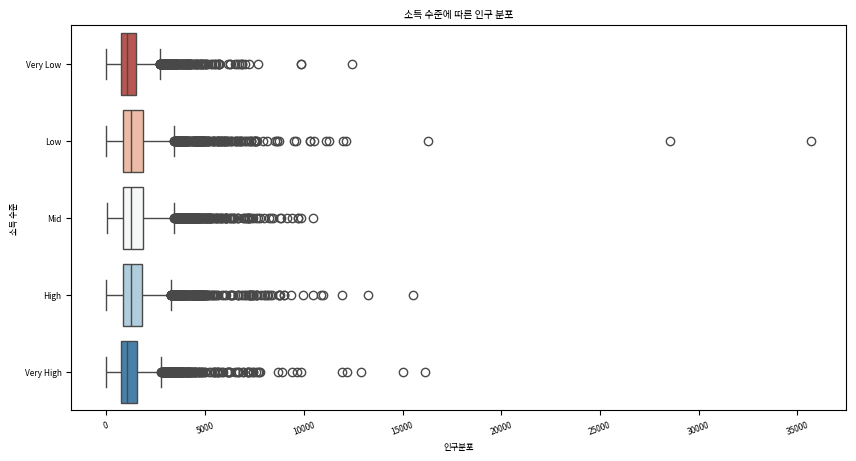

Low 구간에서 몇 개의 이상치 빼고는 주목할 만한 사항 없음 
즉, 해안과 도심에는 인구 차이가 별로 안난다.


In [207]:
# population과 median_income간의 관계를 박스플롯으로 비교
df["price_bin"] = pd.qcut(
    df["median_house_value"],
    q=5,
    labels=["Very Low", "Low", "Mid", "High", "Very High"]
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="population",
    y="price_bin",
    palette = "RdBu"
)
plt.xticks(rotation=20)
plt.title("소득 수준에 따른 인구 분포")
plt.ylabel("소득 수준")
plt.xlabel("인구분포")
plt.show()
print(f"Low 구간에서 몇 개의 이상치 빼고는 주목할 만한 사항 없음 ")
print(f"즉, 해안과 도심에는 인구 차이가 별로 안난다.")

In [208]:
# longitude가 증가(도심)할수록 소득 구간은 낮아진다
₩

SyntaxError: invalid character '₩' (U+20A9) (3577706482.py, line 2)

In [ ]:
import geopandas as gpd  # geopandas를 gpd라는 이름으로 불러온다는 뜻
from shapely.geometry import Point
# 1. SHP 파일과 CSV 파일 불러오기
california_shp = gpd.read_file('/Users/gyulltang/Desktop/GIS/tl_2025_06_tract/tl_2025_06_tract.shp') # 캘리포니아 레이어
df = pd.read_csv('/Users/gyulltang/Desktop/GIS/coastal_analysis.csv')

# 2. CSV 데이터를 공간 데이터로 변환 (Point 객체 생성)
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf_coastal = gpd.GeoDataFrame(df, geometry=geometry)

# 3. 좌표계 설정 (CSV는 일반적으로 EPSG:4326 사용)
gdf_coastal.set_crs(epsg=4326, inplace=True)
california_shp = california_shp.to_crs(epsg=4326)

# 4. 공간 결합 (Spatial Join)
# CSV의 포인트 데이터가 SHP의 어느 폴리곤 안에 있는지 분석
joined_data = gpd.sjoin(gdf_coastal, california_shp, how="left", predicate="within")

# 결과 확인
print(joined_data.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -118.49     34.06                  42         2861           360.0   
1    -118.50     34.05                  39         1487           163.0   
2    -118.52     34.05                  45         1814           325.0   
3    -118.52     34.04                  47         1985           315.0   
4    -118.54     34.05                  33         6778          1092.0   

   population  households  median_income  median_house_value ocean_proximity  \
0         829         310        15.0001              500001       <1H OCEAN   
1         414         160        15.0000              500001       <1H OCEAN   
2         709         311         4.8250              500001       <1H OCEAN   
3         819         340         6.5147              500001       <1H OCEAN   
4        2540        1052         8.5650              500001       <1H OCEAN   

   ...        GEOID               GEOIDFQ     NAME              NAME

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = origin.copy()

# 파생 변수
df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
df["ave_occup"] = df["population"] / df["households"]

features = [
    "median_income",
    "housing_median_age",
    "avg_rooms",
    "avg_bedrooms",
    "population",
    "ave_occup",
    "latitude",
    "longitude"
]


In [ ]:
corr_matrix = df[features].corr()
print(f"1️⃣ “옛날 건축물일수록 집값이 높은가?” → 조건부로 Yes\n결론부터 말하면:\n❌ 단순히 오래됐기 때문에 비싸지 않다\n✅ ‘어디에 있고’, ‘어떤 맥락의 오래됨인가’가 핵심\n즉, 건축 연령은 독립 변수라기보다 ‘위치·희소성·학군’을 대변하는 프록시 변수에 가깝습니다.")
corr_matrix

1️⃣ “옛날 건축물일수록 집값이 높은가?” → 조건부로 Yes
결론부터 말하면:
❌ 단순히 오래됐기 때문에 비싸지 않다
✅ ‘어디에 있고’, ‘어떤 맥락의 오래됨인가’가 핵심
즉, 건축 연령은 독립 변수라기보다 ‘위치·희소성·학군’을 대변하는 프록시 변수에 가깝습니다.


,median_income,housing_median_age,avg_rooms,avg_bedrooms,population,ave_occup,latitude,longitude
median_income,1.000000,-0.119034,0.326895,-0.062299,0.004834,0.018766,-0.079809,-0.015176
housing_median_age,-0.119034,1.000000,-0.153277,-0.077918,-0.296244,0.013191,0.011173,-0.108197
avg_rooms,0.326895,-0.153277,1.000000,0.848616,-0.072213,-0.004852,0.106389,-0.027540
avg_bedrooms,-0.062299,-0.077918,0.848616,1.000000,-0.066510,-0.006179,0.070025,0.013402
population,0.004834,-0.296244,-0.072213,-0.066510,1.000000,0.069863,-0.108785,0.099773
ave_occup,0.018766,0.013191,-0.004852,-0.006179,0.069863,1.000000,0.002366,0.002476
latitude,-0.079809,0.011173,0.106389,0.070025,-0.108785,0.002366,1.000000,-0.924664
longitude,-0.015176,-0.108197,-0.027540,0.013402,0.099773,0.002476,-0.924664,1.000000


✅ ② Robust 회귀 (이상치에 둔감)

In [ ]:
np.isinf(X).sum(), np.isnan(X).sum()


(log_median_inc      0
 latitude            0
 longitude           0
 log_rooms           0
 log_population      0
 ocean_INLAND        0
 ocean_NEAR BAY      0
 ocean_NEAR OCEAN    0
 dtype: int64,
 log_median_inc      0
 latitude            0
 longitude           0
 log_rooms           0
 log_population      0
 ocean_INLAND        0
 ocean_NEAR BAY      0
 ocean_NEAR OCEAN    0
 dtype: int64)

In [ ]:
def rlm_result_to_string(result, alpha=0.05, top_n=5):
    params = result.params
    bse = result.bse
    tvalues = params / bse
    
    # 유의 변수 판단 (근사적 t 기준)
    significant = (np.abs(tvalues) > 1.96)
    
    # 영향력 큰 변수 상위
    top_vars = (
        params.drop("const")
        .abs()
        .sort_values(ascending=False)
        .head(top_n)
        .index.tolist()
    )
    
    lines = []
    lines.append("[Robust Linear Regression (Huber) 결과 요약]\n")
    lines.append("모형 특성:")
    lines.append("- 추정 방법: Robust M-estimation (Huber)")
    lines.append("- 목적: 이상치·상한값(censoring)에 둔감한 계수 추정\n")
    
    lines.append("주요 계수 (상위 영향 변수):")
    for var in top_vars:
        sig = "유의" if significant[var] else "비유의"
        lines.append(
            f"  · {var:<18}: coef={params[var]:>10.3f}, "
            f"SE={bse[var]:>8.3f}, t≈{tvalues[var]:>6.2f} → {sig}"
        )
    
    lines.append("\n[해석]")
    lines.append(
        "- Robust 회귀는 극단값의 영향을 제한하여 계수를 추정함"
    )
    lines.append(
        "- 특히 고가 주택 상한(500001)으로 인한 왜곡을 완화"
    )
    lines.append(
        "- 계수 부호와 상대적 크기는 구조적 관계를 반영"
    )
    
    return "\n".join(lines)


In [ ]:
print(rlm_result_to_string(rlm_result))


[Robust Linear Regression (Huber) 결과 요약]

모형 특성:
- 추정 방법: Robust M-estimation (Huber)
- 목적: 이상치·상한값(censoring)에 둔감한 계수 추정

주요 계수 (상위 영향 변수):
  · avg_bedrooms      : coef= 85201.891, SE=2297.309, t≈ 37.09 → 유의
  · median_income     : coef= 46958.414, SE= 343.125, t≈136.85 → 유의
  · longitude         : coef=-38423.106, SE= 616.141, t≈-62.36 → 유의
  · latitude          : coef=-36534.083, SE= 588.424, t≈-62.09 → 유의
  · avg_rooms         : coef=-13639.731, SE= 480.714, t≈-28.37 → 유의

[해석]
- Robust 회귀는 극단값의 영향을 제한하여 계수를 추정함
- 특히 고가 주택 상한(500001)으로 인한 왜곡을 완화
- 계수 부호와 상대적 크기는 구조적 관계를 반영


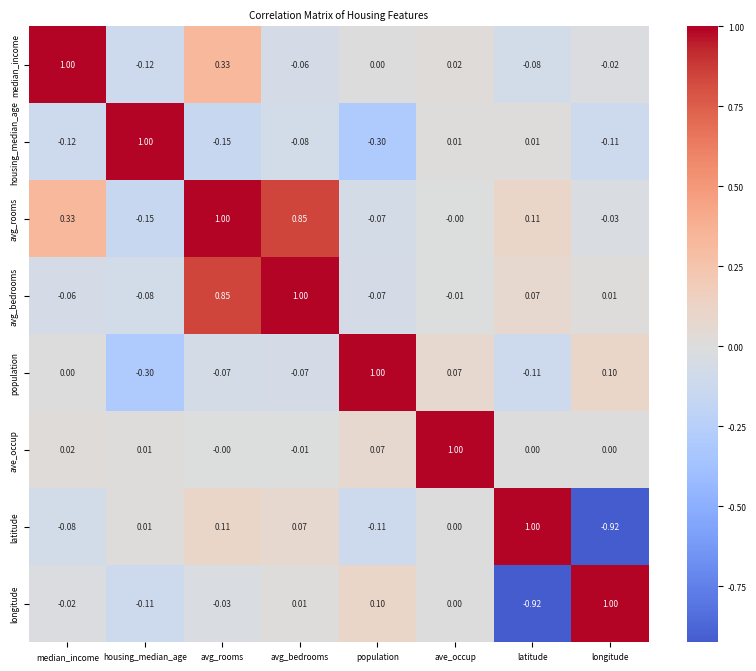

In [ ]:
# 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix of Housing Features")
plt.show()


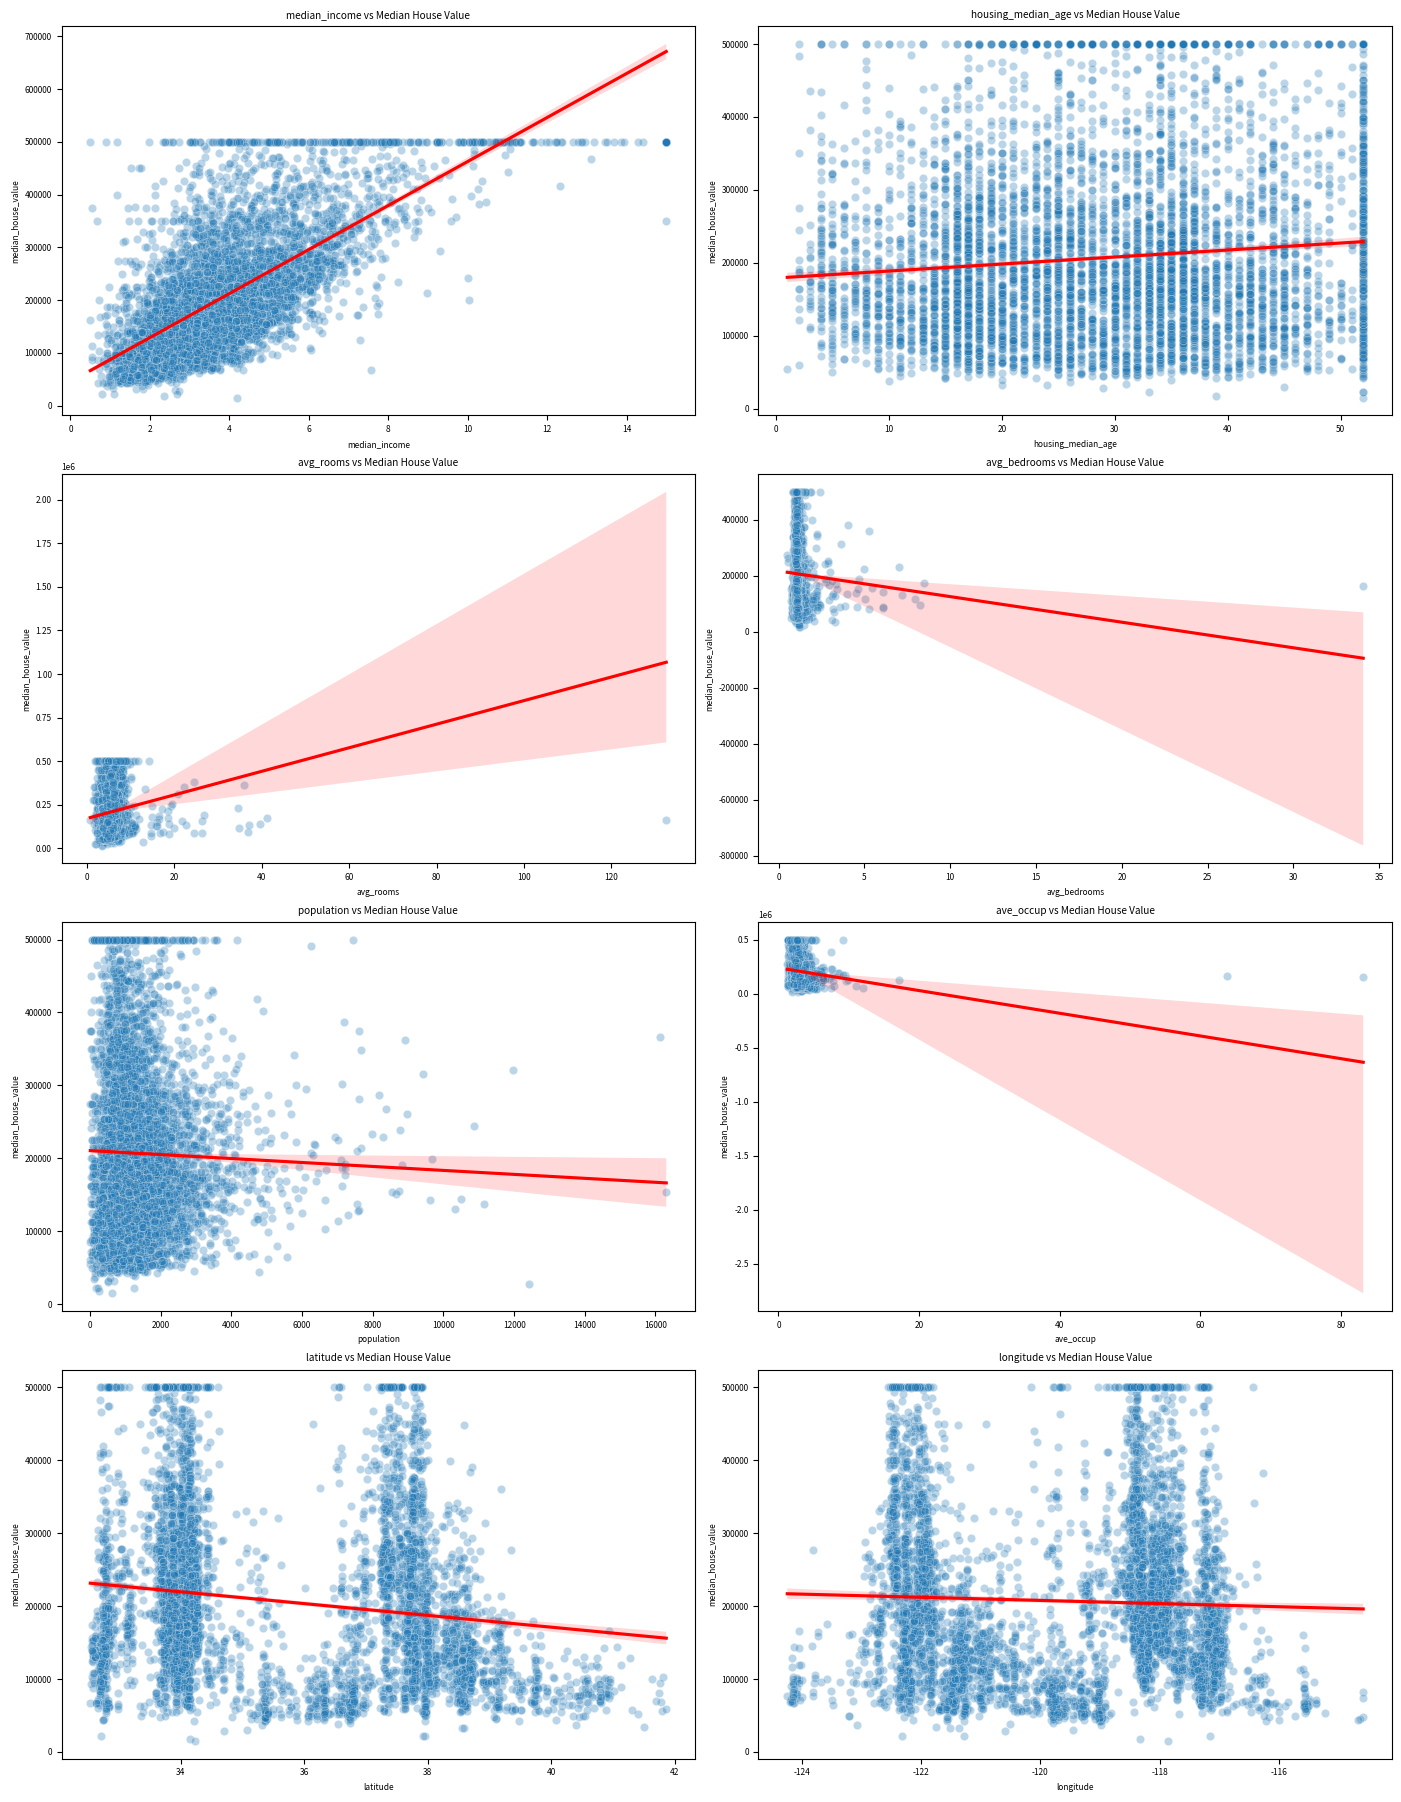

In [ ]:
# 시각화
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.scatterplot(
        data=df.sample(6000, random_state=42),
        x=col,
        y="median_house_value",
        alpha=0.3,
        ax=ax
    )
    sns.regplot(
        data=df.sample(6000, random_state=42),
        x=col,
        y="median_house_value",
        scatter=False,
        ax=ax,
        color="red"
    )
    ax.set_title(f"{col} vs Median House Value")

plt.tight_layout()
plt.show()
print(f"")

특정 좌표(34, -119) 인근에 위치한 주택들만 추출해서<br>
그 지역의 소득, 주택 구조, 밀도, 연령, 가격 특성을<br>
전체 평균과 비교하고 싶다

In [ ]:
df["avg_rooms"] = df["total_rooms"] / df["households"]
df["avg_bedrooms"] = df["total_bedrooms"] / df["households"]
df["bedroom_ratio"] = df["total_bedrooms"] / df["total_rooms"]


In [ ]:
# 기준 좌표 반경 내 주택 추출

# Haversine 함수 정의
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # 지구 반지름 (km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 기준 좌표 설정 + 거리 계산
# 기준 좌표 (Malibu 인근)
target_lat = 34.0
target_lon = -119.0



df["distance_km"] = haversine(
    target_lat,
    target_lon,
    df["latitude"],
    df["longitude"]
)

# 반경 설정 (예: 20km)
radius_km = 20

df_area = df[df["distance_km"] <= radius_km]

print(f"선택된 주택 수: {len(df_area)}")

# 그 지역에 “다른 변수들” 매칭해서 요약하기
# 그 지역에 “다른 변수들” 매칭해서 요약하기
cols = [
    "median_house_value",
    "median_income",
    "housing_median_age",
    "avg_rooms",
    "avg_bedrooms",
    "population"
    
]

df[cols].describe()


선택된 주택 수: 15


,median_house_value,median_income,housing_median_age,avg_rooms,avg_bedrooms,population
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000
mean,206855.816909,3.870671,28.639486,5.429000,1.097062,1425.476744
std,115395.615874,1.899822,12.585558,2.474173,0.476104,1132.462122
min,14999.000000,0.499900,1.000000,0.846154,0.333333,3.000000
25%,119600.000000,2.563400,18.000000,4.440716,1.006029,787.000000
50%,179700.000000,3.534800,29.000000,5.229129,1.048889,1166.000000
75%,264725.000000,4.743250,37.000000,6.052381,1.099631,1725.000000
max,500001.000000,15.000100,52.000000,141.909091,34.066667,35682.000000


In [ ]:
# Malibu 축
malibu = df[
    (df["latitude"].between(33.5, 34.5)) &
    (df["longitude"].between(-120, -118))
]

# SF Bay
sf_bay = df[
    (df["latitude"].between(37.0, 38.0)) &
    (df["longitude"].between(-123, -121))
]

compare_income = pd.DataFrame({
    "Malibu Area": malibu["median_income"].describe(),
    "SF Bay Area": sf_bay["median_income"].describe()
})

compare_income


,Malibu Area,SF Bay Area
count,5995.000000,4120.000000
mean,3.969089,4.501061
std,2.044907,2.123925
min,0.499900,0.499900
25%,2.595100,3.077200
50%,3.581900,4.155300
75%,4.857700,5.500000
max,15.000100,15.000100


연 소득의 몇 배짜리 집인가

In [ ]:
df = origin.copy()

# 0으로 나누는 오류 방지
df = df[df["median_income"] > 0]

df["price_income_ratio"] = (
    df["median_house_value"] /
    (df["median_income"] * 10000)
)

df[["median_house_value", "median_income", "price_income_ratio"]].head()


,median_house_value,median_income,price_income_ratio
0,452600,8.3252,5.436506
1,358500,8.3014,4.318549
2,352100,7.2574,4.851600
3,341300,5.6431,6.048094
4,342200,3.8462,8.897093


In [ ]:
# 지도용 csv 저장
df.to_csv("california_price_income_ratio.csv", index=False)

In [ ]:
df["price_income_ratio"] = (
    df["median_house_value"].astype(float) /
    (df["median_income"].astype(float) * 10000)
)

df.to_csv("california_income_clean.csv", index=False)


## 📝 미션 12. “모형 진단과 개선”

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# =========================
# 1. 데이터 로드
# =========================
df = pd.read_excel("군집.xlsx")

# =========================
# 2. 로그 변환
# =========================
df["log_median_hou"] = np.log(df["median_hou"])
df["log_median_inc"] = np.log(df["median_inc"])
df["log_population"] = np.log(df["population"] + 1)
df["log_rooms"] = np.log(df["total_room"] + 1)

# =========================
# 3. ocean_proximity 더미 (전체 기준)
# =========================
ocean_dummy = pd.get_dummies(
    df["ocean_prox"],
    prefix="ocean",
    drop_first=True
)

df = pd.concat([df, ocean_dummy], axis=1)

# =========================
# 4. 군집별 OLS
# =========================
cluster_models = {}

base_vars = [
    "log_median_inc",
    "latitude",
    "longitude",
    "log_rooms",
    "log_population"
]

dummy_vars = list(ocean_dummy.columns)

for cid in sorted(df["CLUSTER_ID"].unique()):
    print(f"\n========== CLUSTER {cid} ==========")

    sub = df[df["CLUSTER_ID"] == cid].copy()

    if len(sub) < 50:
        print("표본 수 부족 → 스킵")
        continue

    X = sub[base_vars + dummy_vars]
    y = sub["log_median_hou"]

    # 숫자 강제 + 결측 제거
    X = X.apply(pd.to_numeric, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")

    reg_data = pd.concat([X, y], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    X_clean = sm.add_constant(reg_data[X.columns]).astype(float)
    y_clean = reg_data["log_median_hou"].astype(float)

    model = sm.OLS(y_clean, X_clean).fit()
    cluster_models[cid] = model

    print(model.summary())


========== CLUSTER 0 ==========
                            OLS Regression Results                            
Dep. Variable:         log_median_hou   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     63.58
Date:                    목, 15 1 2026   Prob (F-statistic):           2.76e-70
Time:                        21:32:19   Log-Likelihood:                -46.511
No. Observations:                 689   AIC:                             109.0
Df Residuals:                     681   BIC:                             145.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const  

c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\linear_model.py:1966: R

다중공선성 계산

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif_cluster(X):
    X = X.copy()

    # 숫자형 강제
    X = X.apply(pd.to_numeric, errors="coerce")

    # NaN / inf 제거
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    # 🔥 분산 0 변수 제거 (가장 중요)
    X = X.loc[:, X.var() > 0]

    # 변수가 2개 미만이면 VIF 의미 없음
    if X.shape[1] < 2:
        return pd.DataFrame({
            "variable": X.columns,
            "VIF": np.nan
        })

    vif_df = pd.DataFrame()
    vif_df["variable"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif_df.sort_values("VIF", ascending=False)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif_cluster(X):
    X = X.copy()

    # 1️⃣ 숫자형 강제
    X = X.apply(pd.to_numeric, errors="coerce")

    # 2️⃣ NaN / inf 제거
    X = X.replace([np.inf, -np.inf], np.nan).dropna()

    # 3️⃣ 분산 0 변수 제거 (🔥 가장 중요)
    X = X.loc[:, X.var() > 0]

    # 변수 2개 미만이면 VIF 계산 불가
    if X.shape[1] < 2:
        return pd.DataFrame({
            "variable": X.columns,
            "VIF": np.nan
        })

    vif_df = pd.DataFrame({
        "variable": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    return vif_df.sort_values("VIF", ascending=False)

In [ ]:
vif_results = {}

for cid in sorted(df["CLUSTER_ID"].unique()):
    print(f"\n========== CLUSTER {cid} ==========")

    sub = df[df["CLUSTER_ID"] == cid].copy()

    if len(sub) < 50:
        print("표본 수 부족 → 스킵")
        continue

    # 🔥 군집 내부 기준 더미 재생성
    ocean_dummy_sub = pd.get_dummies(
        sub["ocean_prox"],
        prefix="ocean",
        drop_first=True
    ).astype(float)

    X = pd.concat(
        [
            sub[base_vars].astype(float),
            ocean_dummy_sub
        ],
        axis=1
    )

    vif_df = calculate_vif_cluster(X)
    vif_results[cid] = vif_df

    print(vif_df)


========== CLUSTER 0 ==========
           variable          VIF
1          latitude  3225.292237
2         longitude  2971.329290
3         log_rooms   695.260625
4    log_population   476.528631
0    log_median_inc     7.646883
5      ocean_INLAND     6.544689
6  ocean_NEAR OCEAN     2.392803

========== CLUSTER 1 ==========
           variable           VIF
1          latitude  17157.278169
2         longitude  16926.252917
3         log_rooms    592.386956
4    log_population    482.163674
0    log_median_inc     10.948673
5      ocean_INLAND      4.344070
6  ocean_NEAR OCEAN      3.442000

========== CLUSTER 2 ==========
           variable          VIF
1          latitude  5385.449994
2         longitude  5186.915894
3         log_rooms   567.625181
4    log_population   478.901140
5      ocean_INLAND    14.624589
0    log_median_inc     9.095841
6  ocean_NEAR OCEAN     2.001180

========== CLUSTER 3 ==========
         variable          VIF
2       longitude  4621.307879
1     

_다중공선성이 발생하여, VIF < 30으로 기준을 정해 다시 OLS를 적용해보았다._

## VIF < 30을 적용한 뒤 실행한 OLS 

In [ ]:
def reduce_vif_with_fixed_vars(X, fixed_vars, threshold=20):
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_curr = X.copy()

    while True:
        vif = pd.DataFrame({
            "variable": X_curr.columns,
            "VIF": [
                variance_inflation_factor(X_curr.values, i)
                for i in range(X_curr.shape[1])
            ]
        })

        max_vif_row = vif.sort_values("VIF", ascending=False).iloc[0]

        if max_vif_row["VIF"] < threshold:
            break

        if max_vif_row["variable"] in fixed_vars:
            break  # 이론적 고정 변수는 제거하지 않음

        print(f"제거: {max_vif_row['variable']} (VIF={max_vif_row['VIF']:.2f})")
        X_curr = X_curr.drop(columns=max_vif_row["variable"])

    return X_curr, vif 

In [ ]:
fixed_vars = ["latitude", "longitude"]
X_reduced, final_vif = reduce_vif_with_fixed_vars(X, fixed_vars, threshold=20)

In [ ]:
def cluster_ols_report_to_string(cluster_models):
    report = []
    report.append("===== Cluster-wise OLS Regression Results =====\n")

    for cid, model in cluster_models.items():
        report.append(f"-------------------- CLUSTER {cid} --------------------")
        report.append(model.summary().as_text())
        report.append("\nKey notes:")
        report.append(
            "- 계수는 로그 변환된 종속 변수로 인한 준탄력성을 나타냅니다..\n"
            "- 별도로 명시되지 않는 한, 통계적 유의성은 5% 수준에서 평가되었습니다..\n"
            "- 다중공선성과 관련된 강건성 문제는 완화된 VIF 기준을 통해 해결되었습니다.\n"
        )
        report.append("\n")

    return "\n".join(report)


In [ ]:
final_report = cluster_ols_report_to_string(cluster_models)
print(final_report)

===== Cluster-wise OLS Regression Results =====

-------------------- CLUSTER 0 --------------------
                            OLS Regression Results                            
Dep. Variable:         log_median_hou   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     63.58
Date:                    목, 15 1 2026   Prob (F-statistic):           2.76e-70
Time:                        21:32:31   Log-Likelihood:                -46.511
No. Observations:                 689   AIC:                             109.0
Df Residuals:                     681   BIC:                             145.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------

- > VIF < 30이라는 조건을 세운 후 OLS회귀계수를 실행해본 결과, 다중공선성 문제는 해결되었습니다.
- > 알 수 있는 사실은, 모든 군집에서 소득의 회귀계수 값이 가장 높은 것으로 보아, 주택가격에 가장 많은 영향을 주는 변수는 log_median_income으로 볼 수 있습니다. 


## 📝 미션 13. “같은 소득인데 왜 가격은 다를까?”

## 1️⃣ 소득은 필요조건이지 충분조건이 아니다

`median_income`은 주택 가격을 설명하는 가장 강력한 변수 중 하나이지만,  
주택 가격은 단일 요인으로 결정되지 않는다.

동일한 소득 수준을 가진 지역이라 하더라도,  
주택이 위치한 환경과 지역적 맥락에 따라 가격은 크게 달라질 수 있다.  
즉, 소득은 주택 가격 형성의 **필요조건**일 수는 있으나,  
그 자체로 가격을 완전히 설명하는 **충분조건**은 아니다.

---

## 2️⃣ 위치(location)가 가격 격차를 만든다

분석 결과, 위도(`latitude`)와 경도(`longitude`)는  
소득을 통제한 이후에도 주택 가격에 유의미한 영향을 미쳤다.

이는 위치 변수가 단순한 지리 좌표가 아니라,  
해안 접근성, 대도시 인접 여부, 교통 및 상업 인프라 등  
여러 지역적 특성을 간접적으로 대변하는 **프록시 변수**로 작동하고 있음을 의미한다.

같은 소득 수준이라 하더라도  
해안이나 대도시 인근 지역의 주택 가격이 더 높은 것은  
시장 구조상 자연스러운 결과이다.

---

## 3️⃣ 주택 연령은 ‘오래됨’ 그 자체가 핵심이 아니다

`housing_median_age`는 주택 가격과 양(+)의 관계를 보였지만,  
이는 주택이 오래될수록 가치가 높다는 단순한 인과관계로 해석하기 어렵다.

오히려 오래된 주택이 밀집한 지역은  
도심이나 핵심 상권에 위치한 경우가 많으며,  
이로 인해 주택 연령 변수는 위치적·역사적 맥락을 반영하는  
간접적인 지표로 작용한다고 볼 수 있다.

---

## 4️⃣ 고가 주택 상한(censoring)이 분포를 왜곡한다

데이터에는 `median_house_value = 500001`이라는  
인위적인 상한값(censoring)이 존재한다.

이 상한값은 무작위로 발생한 것이 아니라  
고소득 지역에 집중된 구조적 검열로 확인되었으며,  
이로 인해 동일한 소득 구간 내에서도 실제 가격 차이가  
관측 데이터에서는 축소되거나 왜곡되어 나타난다.

이러한 특성은 잔차 분포의 꼬리 왜곡을 유발하며,  
일반적인 OLS 회귀의 가정을 약화시킨다.

---

## 5️⃣ Robust 회귀가 보여주는 구조적 차이

Robust 회귀(Huber M-estimator)는 극단값의 영향을 완화하여  
이상치와 상한값이 존재하는 데이터에서도  
보다 안정적인 계수 추정을 가능하게 한다.

Robust 회귀 결과, 소득의 영향력은 여전히 유의미했으나  
위치 변수의 설명력이 더욱 명확하게 드러났으며,  
같은 소득임에도 주택 가격이 달라지는 현상이  
공간적·구조적 요인에서 비롯됨을 확인할 수 있었다.
